# **Dataset 1: Bangalore EEG Epilepsy Dataset (BEED)**

## **Step 1: Setup & Data Loading**

In [197]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, validation_curve, learning_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             precision_recall_curve, auc, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

FIG_DIR = '/content/figures'
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup complete. Figures will be saved to:', FIG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Figures will be saved to: /content/figures


## Data Loading

In [198]:
df = pd.read_csv('/content/drive/MyDrive/MS DS/Data Mining/BEED_Data.csv')

# Binarize: class 0 = Non-Seizure, classes 1,2,3 = Seizure
df['y'] = df['y'].apply(lambda x: 1 if x in [1, 2, 3] else 0)

print(f'Shape: {df.shape}')
print(f'Non-Seizure: {(df["y"]==0).sum()} | Seizure: {(df["y"]==1).sum()}')
df.head()

Shape: (8000, 17)
Non-Seizure: 2000 | Seizure: 6000


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


## Descriptive Statistics

=== Descriptive Statistics ===
      count      mean        std    min    25%  50%   75%    max
X1   8000.0 -1.490375  36.824213 -281.0  -7.00  0.0   8.0  252.0
X2   8000.0 -2.189375  36.108088 -255.0  -7.00  0.0   8.0  261.0
X3   8000.0 -3.237500  35.802490 -255.0  -7.00 -1.0   5.0  238.0
X4   8000.0 -4.119375  36.285268 -257.0 -10.00 -1.0   7.0  246.0
X5   8000.0 -1.821625  37.621284 -264.0 -10.00  0.0  10.0  249.0
X6   8000.0 -2.311750  36.306006 -277.0  -8.00  0.0   8.0  245.0
X7   8000.0 -3.398125  36.358395 -277.0  -8.00 -1.0   6.0  220.0
X8   8000.0 -3.448625  36.522214 -260.0  -7.00 -1.0   5.0  271.0
X9   8000.0 -1.647875  38.107721 -290.0  -7.00  0.0   8.0  280.0
X10  8000.0 -2.561250  37.540680 -302.0  -8.00  0.0   8.0  251.0
X11  8000.0 -3.524500  37.343938 -276.0  -8.00 -1.0   5.0  262.0
X12  8000.0 -4.782750  37.469582 -306.0 -11.00 -2.0   7.0  283.0
X13  8000.0 -2.164000  38.144075 -288.0 -10.00  0.0  10.0  296.0
X14  8000.0 -2.910875  36.640555 -290.0  -8.00  0.0   9.0  

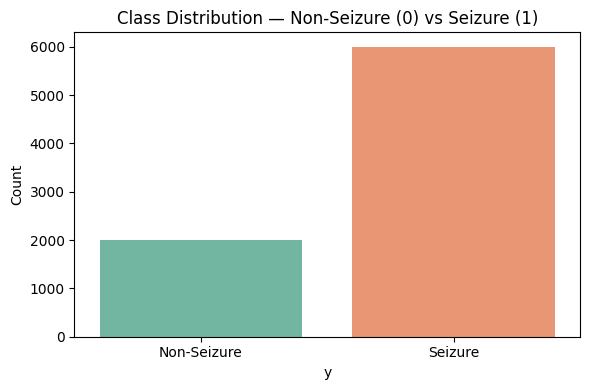

In [199]:
print('=== Descriptive Statistics ===')
print(df.describe().T)

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Class Distribution — Non-Seizure (0) vs Seizure (1)')
plt.xticks([0, 1], ['Non-Seizure', 'Seizure'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap

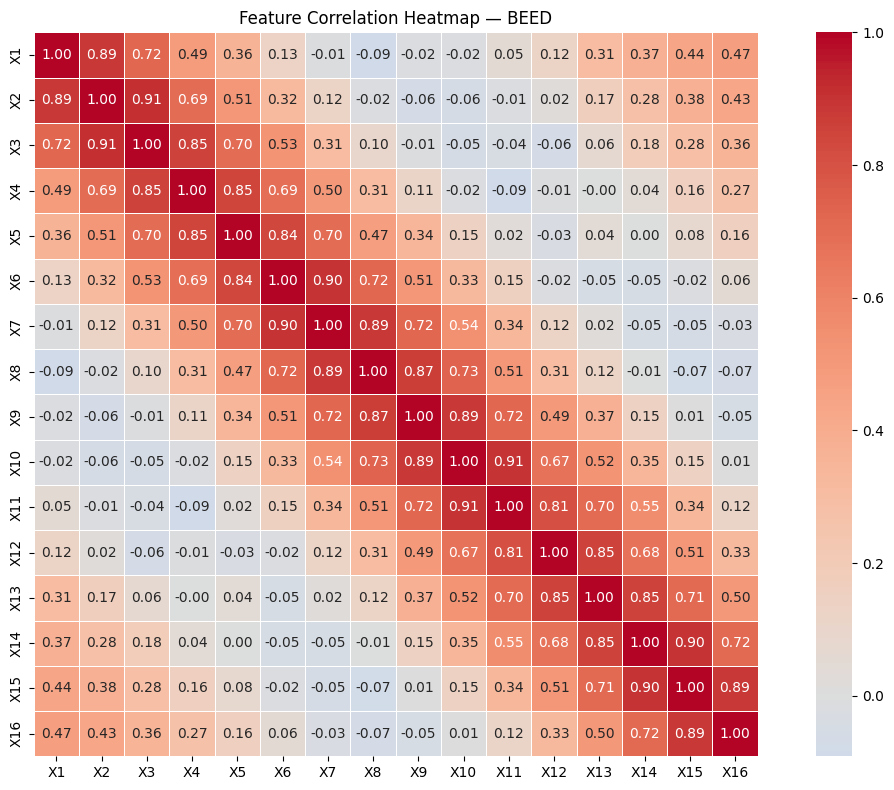

In [200]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['y']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap — BEED')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Missing Value Check

In [201]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))
print(f'\nTotal missing values: {missing.sum()}')
if missing.sum() == 0:
    print('No missing values. Dataset is complete.')

     Missing Count  Missing %
X1               0        0.0
X2               0        0.0
X3               0        0.0
X4               0        0.0
X5               0        0.0
X6               0        0.0
X7               0        0.0
X8               0        0.0
X9               0        0.0
X10              0        0.0
X11              0        0.0
X12              0        0.0
X13              0        0.0
X14              0        0.0
X15              0        0.0
X16              0        0.0
y                0        0.0

Total missing values: 0
No missing values. Dataset is complete.


## **Step 2: Preprocessing Pipelines**

## Train/Test Split

In [202]:
# Split BEFORE preprocessing to prevent data leakage
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class distribution:\n{y_train.value_counts()}')

Train: (6400, 16) | Test: (1600, 16)
Train class distribution:
y
1    4800
0    1600
Name: count, dtype: int64


## Pipeline A — Step 1: Outlier Clipping (IQR)

In [203]:
# IQR boundaries fitted on train only
Q1, Q3 = X_train.quantile(0.25), X_train.quantile(0.75)
IQR    = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

X_A_tr = X_train.clip(lower=lower, upper=upper, axis=1)
X_A_te = X_test.clip(lower=lower, upper=upper, axis=1)
print(f'IQR Clipping done. Range: [{X_A_tr.min().min():.2f}, {X_A_tr.max().max():.2f}]')

IQR Clipping done. Range: [-40.00, 40.00]


## Pipeline A — Step 2: MinMax Normalization

In [204]:
# Scaler fitted on train only, applied to both
scaler_A = MinMaxScaler()
X_A_tr   = pd.DataFrame(scaler_A.fit_transform(X_A_tr), columns=X_train.columns)
X_A_te   = pd.DataFrame(scaler_A.transform(X_A_te),     columns=X_train.columns)
print(f'MinMax Scaling done. Range: [{X_A_tr.min().min():.2f}, {X_A_tr.max().max():.2f}]')

MinMax Scaling done. Range: [0.00, 1.00]


## Pipeline A — Step 3: ANOVA Feature Selection

Feature Selection done. Selected 10 features: ['X1', 'X5', 'X6', 'X9', 'X10', 'X11', 'X13', 'X14', 'X15', 'X16']


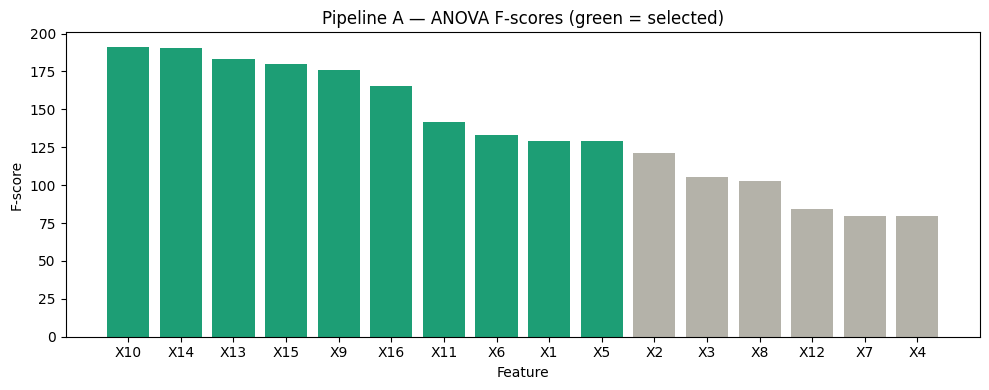

In [205]:
# Selector fitted on train only
selector  = SelectKBest(f_classif, k=10)
X_A_train = pd.DataFrame(selector.fit_transform(X_A_tr, y_train),
                          columns=X_train.columns[selector.get_support()])
X_A_test  = pd.DataFrame(selector.transform(X_A_te),
                          columns=X_train.columns[selector.get_support()])

selected = X_A_train.columns.tolist()
print(f'Feature Selection done. Selected 10 features: {selected}')

# ANOVA score bar chart
all_scores = pd.Series(selector.scores_, index=X_train.columns).sort_values(ascending=False)
colors     = ['#1D9E75' if f in selected else '#B4B2A9' for f in all_scores.index]
plt.figure(figsize=(10, 4))
plt.bar(all_scores.index, all_scores.values, color=colors)
plt.title('Pipeline A — ANOVA F-scores (green = selected)')
plt.xlabel('Feature'); plt.ylabel('F-score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_04_pipeline_A_anova.png', dpi=150, bbox_inches='tight')
plt.show()

## Pipeline B — Step 1: Z-score Standardization

In [206]:
# Scaler fitted on train only
scaler_B = StandardScaler()
X_B_tr   = pd.DataFrame(scaler_B.fit_transform(X_train), columns=X_train.columns)
X_B_te   = pd.DataFrame(scaler_B.transform(X_test),      columns=X_train.columns)
print(f'Standardization done. Mean~0: {X_B_tr.mean().mean():.4f}, Std~1: {X_B_tr.std().mean():.4f}')

Standardization done. Mean~0: 0.0000, Std~1: 1.0001


## Pipeline B — Step 2: PCA

PCA done. Components: 6, Variance retained: 95.34%


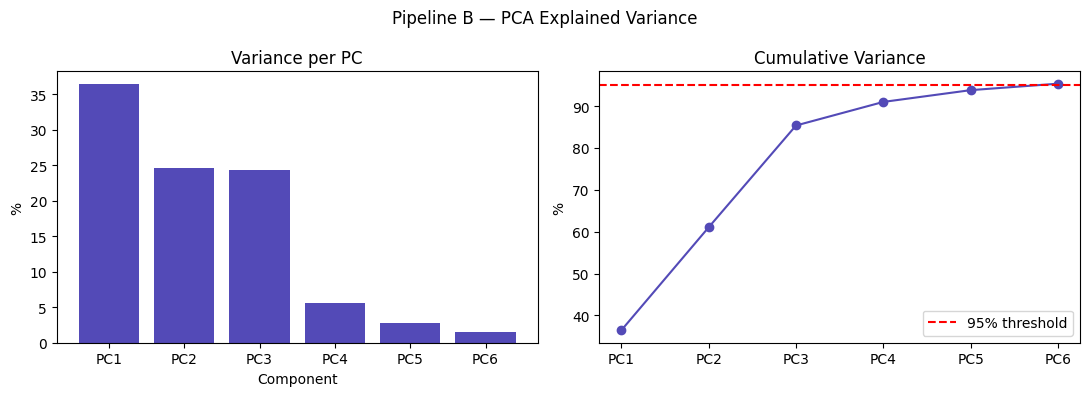

In [207]:
# PCA fitted on train only
pca      = PCA(n_components=0.95, random_state=42)
pc_cols  = [f'PC{i+1}' for i in range(pca.fit(X_B_tr).n_components_)]
X_B_train = pd.DataFrame(pca.fit_transform(X_B_tr), columns=pc_cols)
X_B_test  = pd.DataFrame(pca.transform(X_B_te),     columns=pc_cols)
cum_var   = np.cumsum(pca.explained_variance_ratio_)
print(f'PCA done. Components: {pca.n_components_}, Variance retained: {cum_var[-1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(pc_cols, pca.explained_variance_ratio_*100, color='#534AB7')
axes[0].set_title('Variance per PC'); axes[0].set_ylabel('%'); axes[0].set_xlabel('Component')
axes[1].plot(pc_cols, cum_var*100, marker='o', color='#534AB7')
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Variance'); axes[1].set_ylabel('%'); axes[1].legend()
plt.suptitle('Pipeline B — PCA Explained Variance')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_05_pipeline_B_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 3: Baseline Logistic Regression**

## Train Baseline Model

In [208]:
lr_A = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_B = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_A.fit(X_A_train, y_train)
lr_B.fit(X_B_train, y_train)

# Evaluate
def get_metrics(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    p, r, _ = precision_recall_curve(y_te, y_prob)
    pr_auc   = auc(r, p)
    print(f'{name} → Accuracy: {acc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f}')
    return {'name': name, 'accuracy': acc, 'f1': f1, 'pr_auc': pr_auc}

print('=== Baseline Results ===')
res_A = get_metrics(lr_A, X_A_test, y_test, 'Pipeline A')
res_B = get_metrics(lr_B, X_B_test, y_test, 'Pipeline B')

=== Baseline Results ===
Pipeline A → Accuracy: 0.6687 | F1: 0.7613 | PR-AUC: 0.7462
Pipeline B → Accuracy: 0.8319 | F1: 0.8923 | PR-AUC: 0.7257


## Classification Report

In [209]:
labels = ['Non-Seizure', 'Seizure']
print('=== Pipeline A — Classification Report ===')
print(classification_report(y_test, lr_A.predict(X_A_test), target_names=labels))
print('=== Pipeline B — Classification Report ===')
print(classification_report(y_test, lr_B.predict(X_B_test), target_names=labels))

=== Pipeline A — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.39      0.56      0.46       400
     Seizure       0.83      0.70      0.76      1200

    accuracy                           0.67      1600
   macro avg       0.61      0.63      0.61      1600
weighted avg       0.72      0.67      0.69      1600

=== Pipeline B — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.72      0.54      0.62       400
     Seizure       0.86      0.93      0.89      1200

    accuracy                           0.83      1600
   macro avg       0.79      0.74      0.75      1600
weighted avg       0.82      0.83      0.82      1600



## Confusion Matrix

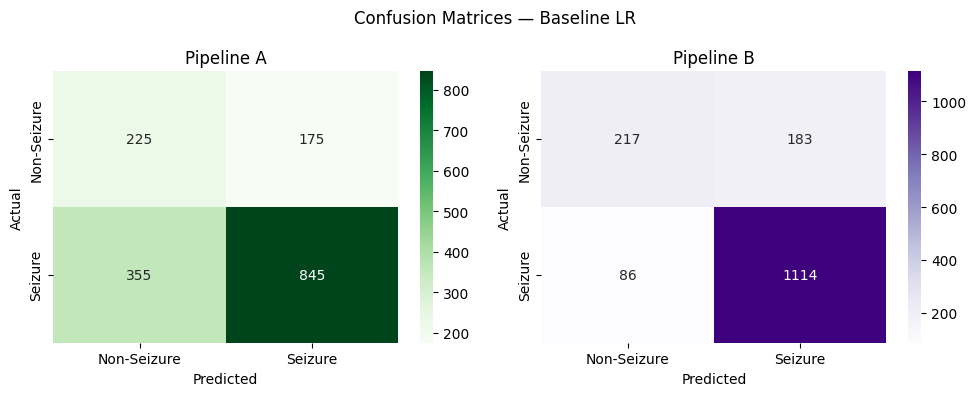

In [210]:
labels = ['Non-Seizure', 'Seizure']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, X_te, title, cmap in zip(
    axes, [lr_A, lr_B], [X_A_test, X_B_test],
    ['Pipeline A', 'Pipeline B'], ['Greens', 'Purples']
):
    cm = confusion_matrix(y_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Baseline LR')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_06_baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Baseline Results Comparison

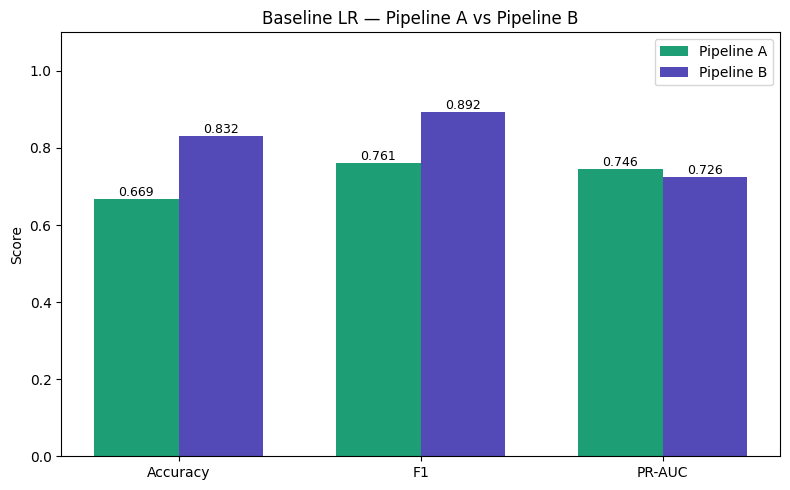

In [211]:
metrics_keys   = ['accuracy', 'f1', 'pr_auc']
metrics_labels = ['Accuracy', 'F1', 'PR-AUC']
x = np.arange(len(metrics_keys)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [res_A[m] for m in metrics_keys], w, label='Pipeline A', color='#1D9E75')
ax.bar(x + w/2, [res_B[m] for m in metrics_keys], w, label='Pipeline B', color='#534AB7')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Baseline LR — Pipeline A vs Pipeline B')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_07_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 4: Overfitting & Underfitting**

## Underfitting Scenario

In [212]:
# Only 2 features + very strong regularization
X_u_tr = X_A_train.iloc[:, :2]
X_u_te = X_A_test.iloc[:, :2]

lr_under = LogisticRegression(C=0.0001, max_iter=1000, random_state=42, class_weight='balanced')
lr_under.fit(X_u_tr, y_train)

tr_acc = lr_under.score(X_u_tr, y_train)
te_acc = lr_under.score(X_u_te, y_test)
print('=== Underfitting Scenario ===')
print(f'Features used  : {X_u_tr.columns.tolist()}')
print(f'C              : 0.0001 (very strong regularization)')
print(f'Train Accuracy : {tr_acc:.4f}')
print(f'Test  Accuracy : {te_acc:.4f}')
print(f'Gap            : {tr_acc - te_acc:.4f}')
print('Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)')

=== Underfitting Scenario ===
Features used  : ['X1', 'X5']
C              : 0.0001 (very strong regularization)
Train Accuracy : 0.5659
Test  Accuracy : 0.5469
Gap            : 0.0191
Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)


## Overfitting Scenario

In [213]:
# Polynomial feature expansion + no regularization
poly   = PolynomialFeatures(degree=3, include_bias=False)
X_o_tr = poly.fit_transform(X_A_train)
X_o_te = poly.transform(X_A_test)

lr_over = LogisticRegression(C=10000, max_iter=1000, random_state=42, class_weight='balanced')
lr_over.fit(X_o_tr, y_train)

tr_acc = lr_over.score(X_o_tr, y_train)
te_acc = lr_over.score(X_o_te, y_test)
print('=== Overfitting Scenario ===')
print(f'Features after polynomial expansion : {X_o_tr.shape[1]}')
print(f'C                                   : 10000 (minimal regularization)')
print(f'Train Accuracy                      : {tr_acc:.4f}')
print(f'Test  Accuracy                      : {te_acc:.4f}')
print(f'Gap                                 : {tr_acc - te_acc:.4f}')
print('NOTE: Small gap is expected — LR is structurally resistant to overfitting.')

=== Overfitting Scenario ===
Features after polynomial expansion : 285
C                                   : 10000 (minimal regularization)
Train Accuracy                      : 0.9986
Test  Accuracy                      : 0.9962
Gap                                 : 0.0023
NOTE: Small gap is expected — LR is structurally resistant to overfitting.


## Validation Curve

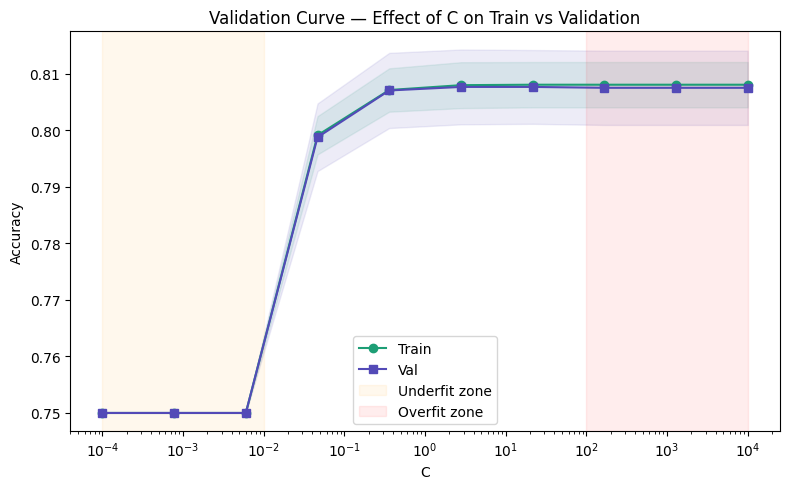

In [214]:
C_range = np.logspace(-4, 4, 10)
tr_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_A_train, y_train, param_name='C', param_range=C_range,
    cv=5, scoring='accuracy', n_jobs=-1
)
tr_mean, tr_std = tr_scores.mean(axis=1), tr_scores.std(axis=1)
v_mean,  v_std  = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(C_range, tr_mean, label='Train', color='#1D9E75', marker='o')
plt.semilogx(C_range, v_mean,  label='Val',   color='#534AB7', marker='s')
plt.fill_between(C_range, tr_mean-tr_std, tr_mean+tr_std, alpha=0.1, color='#1D9E75')
plt.fill_between(C_range, v_mean-v_std,   v_mean+v_std,   alpha=0.1, color='#534AB7')
plt.axvspan(1e-4, 1e-2, alpha=0.07, color='orange', label='Underfit zone')
plt.axvspan(1e2,  1e4,  alpha=0.07, color='red',    label='Overfit zone')
plt.xlabel('C'); plt.ylabel('Accuracy')
plt.title('Validation Curve — Effect of C on Train vs Validation')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_08_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Curves

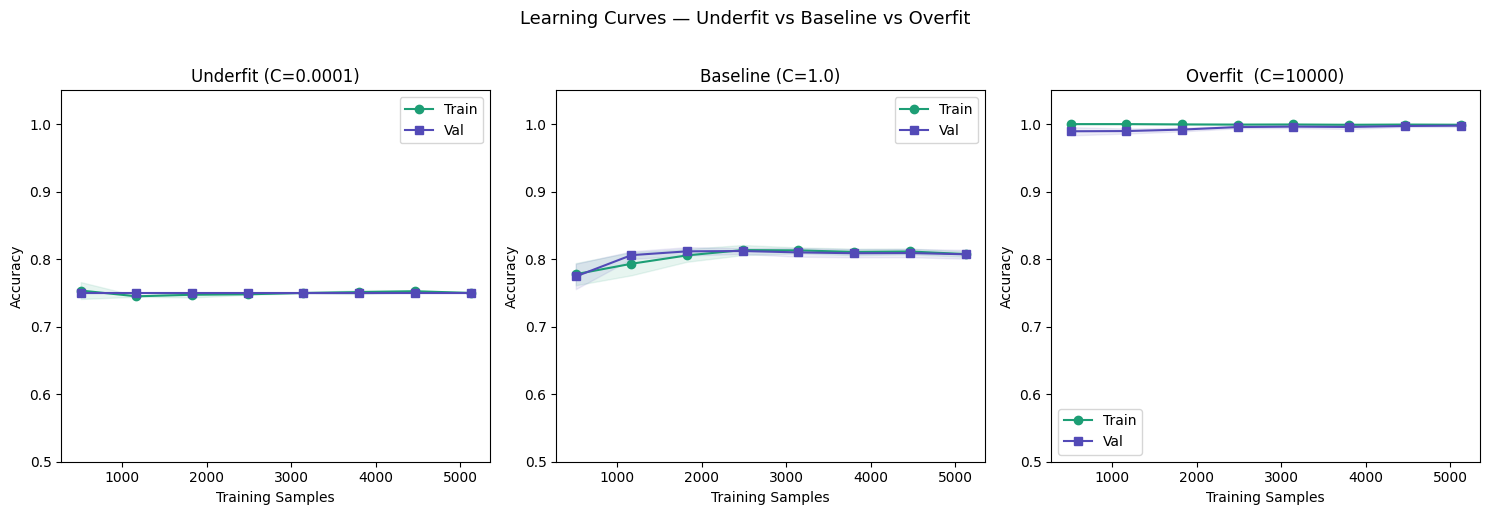

In [215]:
train_sizes = np.linspace(0.1, 1.0, 8)
scenarios   = [
    ('Underfit (C=0.0001)', LogisticRegression(C=0.0001, max_iter=1000, random_state=42), X_u_tr, y_train),
    ('Baseline (C=1.0)',    LogisticRegression(C=1.0,    max_iter=1000, random_state=42), X_A_train, y_train),
    ('Overfit  (C=10000)',  LogisticRegression(C=10000,  max_iter=1000, random_state=42), X_o_tr, y_train),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, model, X_lc, y_lc) in zip(axes, scenarios):
    sizes, tr_s, v_s = learning_curve(
        model, X_lc, y_lc, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1
    )
    ax.plot(sizes, tr_s.mean(axis=1), label='Train', color='#1D9E75', marker='o')
    ax.plot(sizes, v_s.mean(axis=1),  label='Val',   color='#534AB7', marker='s')
    ax.fill_between(sizes, tr_s.mean(axis=1)-tr_s.std(axis=1),
                           tr_s.mean(axis=1)+tr_s.std(axis=1), alpha=0.1, color='#1D9E75')
    ax.fill_between(sizes, v_s.mean(axis=1)-v_s.std(axis=1),
                           v_s.mean(axis=1)+v_s.std(axis=1),   alpha=0.1, color='#534AB7')
    ax.set_title(label); ax.set_xlabel('Training Samples'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.set_ylim(0.5, 1.05)
plt.suptitle('Learning Curves — Underfit vs Baseline vs Overfit', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_09_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting & Underfitting Results Summary

In [216]:
summary_ou = pd.DataFrame([
    {'Scenario': 'Underfitting', 'C': 0.0001, 'Features': 2,
     'Train Acc': round(lr_under.score(X_u_tr, y_train), 4),
     'Test Acc' : round(lr_under.score(X_u_te, y_test),  4)},
    {'Scenario': 'Baseline',    'C': 1.0,    'Features': X_A_train.shape[1],
     'Train Acc': round(lr_A.score(X_A_train, y_train),  4),
     'Test Acc' : round(lr_A.score(X_A_test,  y_test),   4)},
    {'Scenario': 'Overfitting', 'C': 10000,  'Features': X_o_tr.shape[1],
     'Train Acc': round(lr_over.score(X_o_tr, y_train),  4),
     'Test Acc' : round(lr_over.score(X_o_te, y_test),   4)},
])
summary_ou['Gap'] = (summary_ou['Train Acc'] - summary_ou['Test Acc']).round(4)
print('=== Overfitting / Underfitting Results Summary ===')
summary_ou

=== Overfitting / Underfitting Results Summary ===


,Scenario,C,Features,Train Acc,Test Acc,Gap
0,Underfitting,0.0001,2,0.5659,0.5469,0.0190
1,Baseline,1.0000,10,0.6745,0.6687,0.0058
2,Overfitting,10000.0000,285,0.9986,0.9962,0.0024


## **Step 5: Regularization Study**

## Train L1, L2 and ElasticNet

In [217]:
# Train all three regularizers on both pipelines
reg_configs = {
    'L1 (Lasso)': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000, random_state=42),
    'L2 (Ridge)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',     max_iter=1000, random_state=42),
    'ElasticNet' : SGDClassifier(loss='modified_huber', penalty='elasticnet',
                                 l1_ratio=0.5, alpha=0.001, max_iter=1000, random_state=42),
}

import copy
trained_A, trained_B, reg_rows = {}, {}, []
for name, model in reg_configs.items():
    m_A = copy.deepcopy(model); m_A.fit(X_A_train, y_train); trained_A[name] = m_A
    m_B = copy.deepcopy(model); m_B.fit(X_B_train, y_train); trained_B[name] = m_B
    for pipe, m, X_te in [('Pipeline A', m_A, X_A_test), ('Pipeline B', m_B, X_B_test)]:
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y_test, y_prob)
        reg_rows.append({'Regularizer': name, 'Pipeline': pipe,
                         'Accuracy': round(accuracy_score(y_test, y_pred), 4),
                         'F1':       round(f1_score(y_test, y_pred), 4),
                         'PR-AUC':   round(auc(r, p), 4)})

reg_metrics_df = pd.DataFrame(reg_rows)
print('=== Regularization Metrics ===')
print(reg_metrics_df.to_string(index=False))

=== Regularization Metrics ===
Regularizer   Pipeline  Accuracy     F1  PR-AUC
 L1 (Lasso) Pipeline A    0.8081 0.8866  0.7423
 L1 (Lasso) Pipeline B    0.8113 0.8882  0.7260
 L2 (Ridge) Pipeline A    0.8081 0.8866  0.7424
 L2 (Ridge) Pipeline B    0.8113 0.8882  0.7260
 ElasticNet Pipeline A    0.8512 0.9097  0.7209
 ElasticNet Pipeline B    0.7500 0.8571  0.7042


## Coefficient Sparsity Analysis

=== Sparsity Analysis (Pipeline A) ===
  L1 (Lasso)      → Zero coefficients: 0/10 | Sparsity: 0.0%
  L2 (Ridge)      → Zero coefficients: 0/10 | Sparsity: 0.0%
  ElasticNet      → Zero coefficients: 2/10 | Sparsity: 20.0%


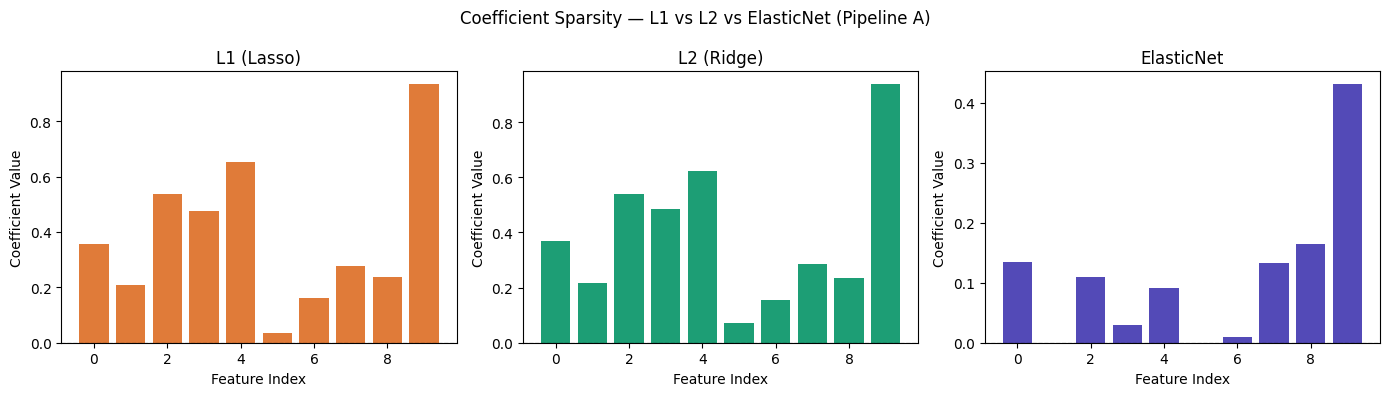

In [218]:
print('=== Sparsity Analysis (Pipeline A) ===')
for name, model in trained_A.items():
    if hasattr(model, 'coef_'):
        coefs = model.coef_.flatten()
        zeros = (np.abs(coefs) < 1e-4).sum()
        print(f'  {name:15} → Zero coefficients: {zeros}/{len(coefs)} | Sparsity: {zeros/len(coefs)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model), color in zip(axes, trained_A.items(), ['#E07B39', '#1D9E75', '#534AB7']):
    coefs = model.coef_.flatten()
    ax.bar(range(len(coefs)), coefs, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(name); ax.set_xlabel('Feature Index'); ax.set_ylabel('Coefficient Value')
plt.suptitle('Coefficient Sparsity — L1 vs L2 vs ElasticNet (Pipeline A)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_10_coefficient_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Path — L1 vs L2

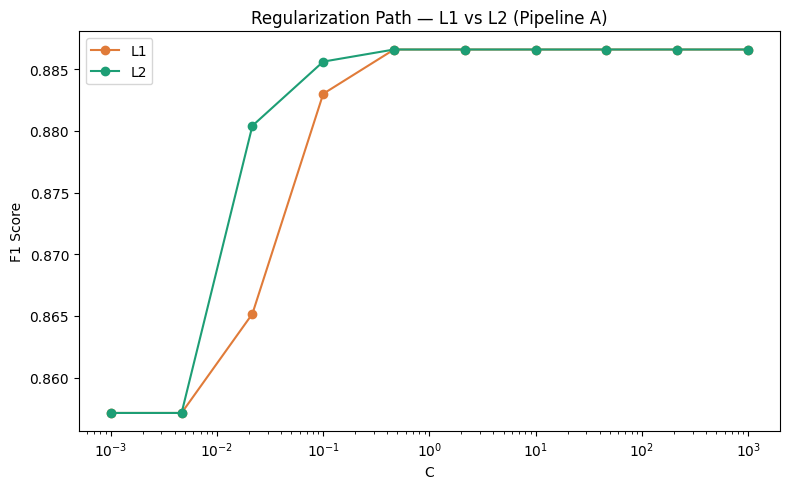

In [219]:
C_range = np.logspace(-3, 3, 10)
plt.figure(figsize=(8, 5))
for penalty, solver, color, label in [
    ('l1', 'liblinear', '#E07B39', 'L1'),
    ('l2', 'lbfgs',     '#1D9E75', 'L2'),
]:
    f1s = []
    for C in C_range:
        m = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=1000, random_state=42)
        m.fit(X_A_train, y_train)
        f1s.append(f1_score(y_test, m.predict(X_A_test)))
    plt.semilogx(C_range, f1s, marker='o', color=color, label=label)
plt.xlabel('C'); plt.ylabel('F1 Score')
plt.title('Regularization Path — L1 vs L2 (Pipeline A)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_12_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Results Summary

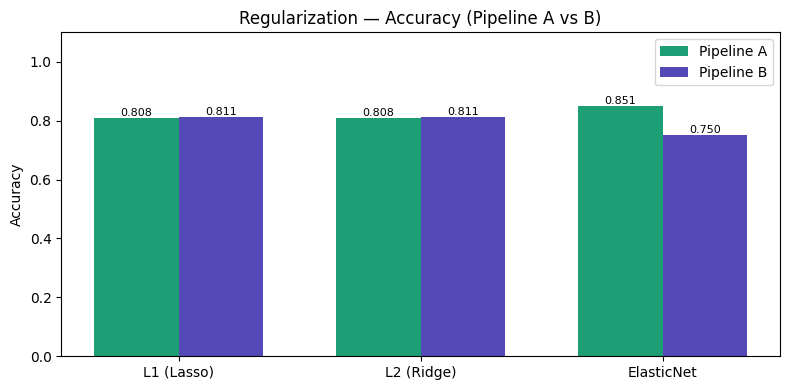

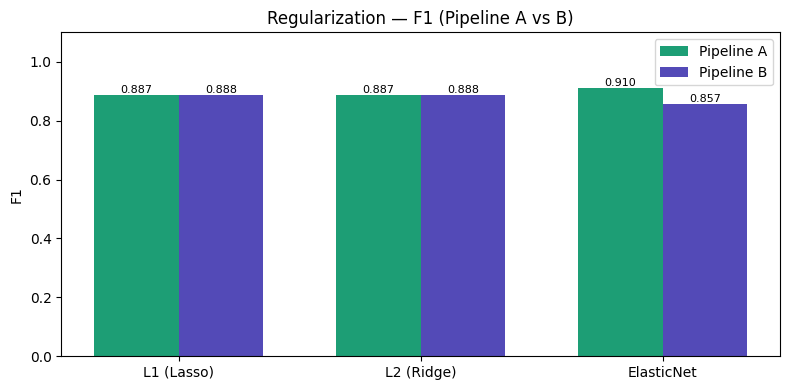

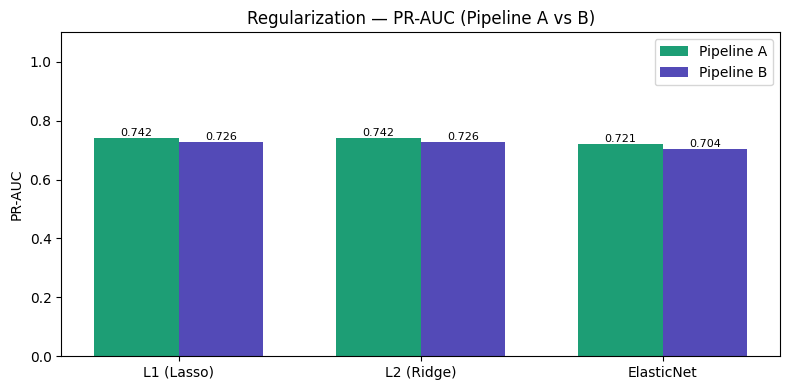

In [220]:
reg_names = reg_metrics_df['Regularizer'].unique().tolist()
x = np.arange(len(reg_names)); w = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [reg_metrics_df[(reg_metrics_df.Regularizer==n) & (reg_metrics_df.Pipeline=='Pipeline A')][metric].values[0] for n in reg_names]
    vals_B = [reg_metrics_df[(reg_metrics_df.Regularizer==n) & (reg_metrics_df.Pipeline=='Pipeline B')][metric].values[0] for n in reg_names]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, vals_A, w, label='Pipeline A', color='#1D9E75')
    ax.bar(x + w/2, vals_B, w, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x); ax.set_xticklabels(reg_names)
    ax.set_ylim(0, 1.1); ax.set_ylabel(metric)
    ax.set_title(f'Regularization — {metric} (Pipeline A vs B)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/beed_13_reg_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Step 6: Class Imbalance Handling**

## Apply Sampling Techniques

In [221]:
smote = SMOTE(random_state=42)
rus   = RandomUnderSampler(random_state=42)

X_smote_A, y_smote_A = smote.fit_resample(X_A_train, y_train)
X_under_A, y_under_A = rus.fit_resample(X_A_train,   y_train)
X_smote_B, y_smote_B = smote.fit_resample(X_B_train, y_train)
X_under_B, y_under_B = rus.fit_resample(X_B_train,   y_train)

configs = {
    'Baseline'     : {'A': (X_A_train, y_train),   'B': (X_B_train, y_train),   'cw': 'balanced'},
    'SMOTE'        : {'A': (X_smote_A, y_smote_A), 'B': (X_smote_B, y_smote_B), 'cw': None},
    'Undersampling': {'A': (X_under_A, y_under_A), 'B': (X_under_B, y_under_B), 'cw': None},
    'Class Weight' : {'A': (X_A_train, y_train),   'B': (X_B_train, y_train),   'cw': 'balanced'},
}

imb_trained, imb_rows = {}, []
for name, data in configs.items():
    for pipe, X_te in [('A', X_A_test), ('B', X_B_test)]:
        X_tr, y_tr = data[pipe]
        cw = data['cw']
        m = LogisticRegression(class_weight=cw, max_iter=1000, random_state=42)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y_test, y_prob)
        imb_rows.append({
            'Technique': name,
            'Pipeline' : f'Pipeline {pipe}',
            'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
            'F1'       : round(f1_score(y_test, y_pred), 4),
            'PR-AUC'   : round(auc(r, p), 4),
        })
        imb_trained[f'{name}_{pipe}'] = m

imb_df = pd.DataFrame(imb_rows)
print('=== Imbalance Handling Results ===')
print(imb_df.to_string(index=False))

=== Imbalance Handling Results ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.6687 0.7613  0.7462
     Baseline Pipeline B    0.8319 0.8923  0.7257
        SMOTE Pipeline A    0.6750 0.7656  0.7464
        SMOTE Pipeline B    0.8337 0.8933  0.7272
Undersampling Pipeline A    0.6431 0.7387  0.7475
Undersampling Pipeline B    0.8337 0.8938  0.7253
 Class Weight Pipeline A    0.6687 0.7613  0.7462
 Class Weight Pipeline B    0.8319 0.8923  0.7257


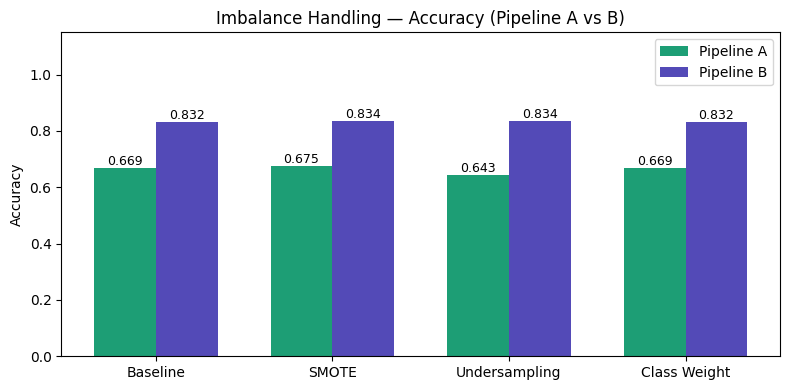

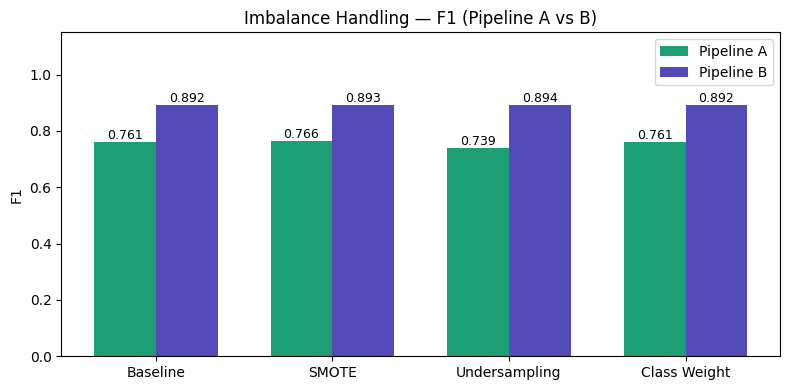

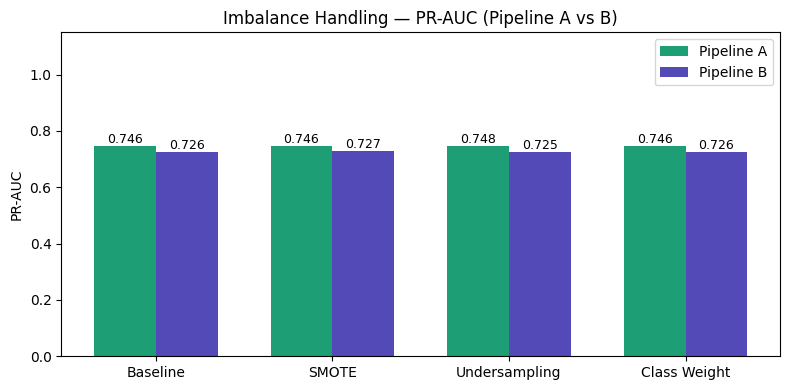

In [222]:
# Bar charts
techniques = list(configs.keys())
x = np.arange(len(techniques)); w = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [imb_df[(imb_df.Technique==t) & (imb_df.Pipeline=='Pipeline A')][metric].values[0] for t in techniques]
    vals_B = [imb_df[(imb_df.Technique==t) & (imb_df.Pipeline=='Pipeline B')][metric].values[0] for t in techniques]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, vals_A, w, label='Pipeline A', color='#1D9E75')
    ax.bar(x + w/2, vals_B, w, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x); ax.set_xticklabels(techniques)
    ax.set_ylim(0, 1.15); ax.set_ylabel(metric)
    ax.set_title(f'Imbalance Handling — {metric} (Pipeline A vs B)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/imbalance_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Precision-Recall Curves

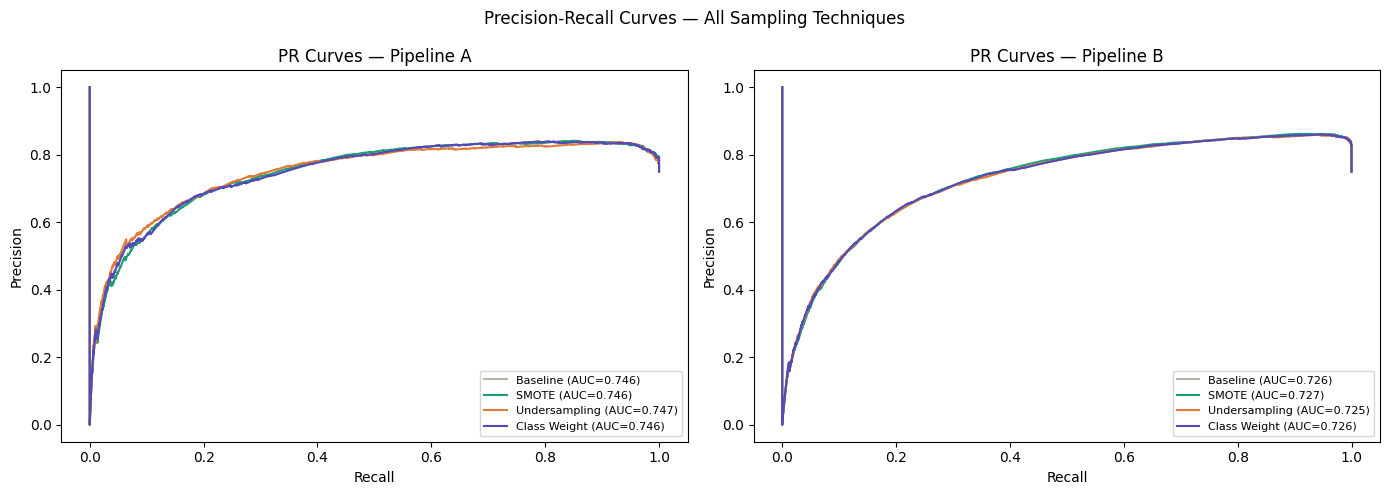

In [223]:
techniques  = imb_df['Technique'].unique().tolist()
colors_tech = ['#B4B2A9', '#1D9E75', '#E07B39', '#534AB7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pipe, X_te) in zip(axes, [('A', X_A_test), ('B', X_B_test)]):
    for tech, color in zip(techniques, colors_tech):
        y_prob = imb_trained[f'{tech}_{pipe}'].predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y_test, y_prob)
        ax.plot(r, p, color=color, label=f'{tech} (AUC={auc(r,p):.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — Pipeline {pipe}'); ax.legend(fontsize=8)
plt.suptitle('Precision-Recall Curves — All Sampling Techniques')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/beed_14_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Reports

In [224]:
labels_cls = ['Non-Seizure', 'Seizure']
for pipe, X_te in [('A', X_A_test), ('B', X_B_test)]:
    print(f'\n{"="*55}')
    print(f'  Pipeline {pipe} — Classification Reports')
    print(f'{"="*55}')
    for tech in techniques:
        y_pred = imb_trained[f'{tech}_{pipe}'].predict(X_te)
        print(f'\n--- {tech} ---')
        print(classification_report(y_test, y_pred, target_names=labels_cls))


  Pipeline A — Classification Reports

--- Baseline ---
              precision    recall  f1-score   support

 Non-Seizure       0.39      0.56      0.46       400
     Seizure       0.83      0.70      0.76      1200

    accuracy                           0.67      1600
   macro avg       0.61      0.63      0.61      1600
weighted avg       0.72      0.67      0.69      1600


--- SMOTE ---
              precision    recall  f1-score   support

 Non-Seizure       0.40      0.58      0.47       400
     Seizure       0.83      0.71      0.77      1200

    accuracy                           0.68      1600
   macro avg       0.62      0.64      0.62      1600
weighted avg       0.72      0.68      0.69      1600


--- Undersampling ---
              precision    recall  f1-score   support

 Non-Seizure       0.36      0.56      0.44       400
     Seizure       0.82      0.67      0.74      1200

    accuracy                           0.64      1600
   macro avg       0.59      0.61

## Confusion Matrices

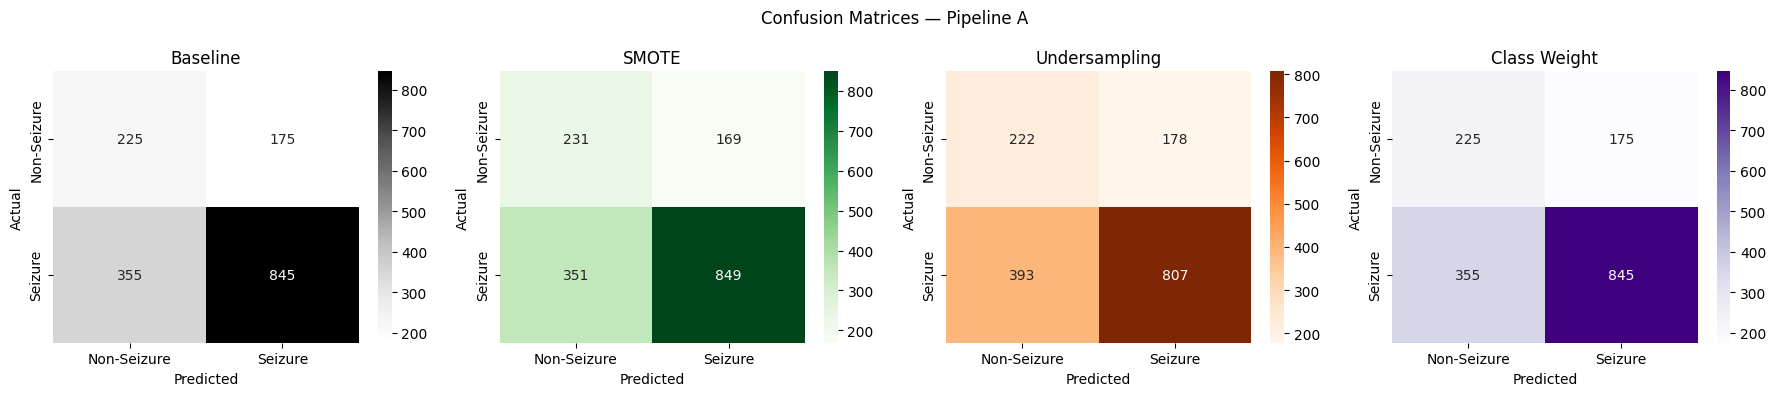

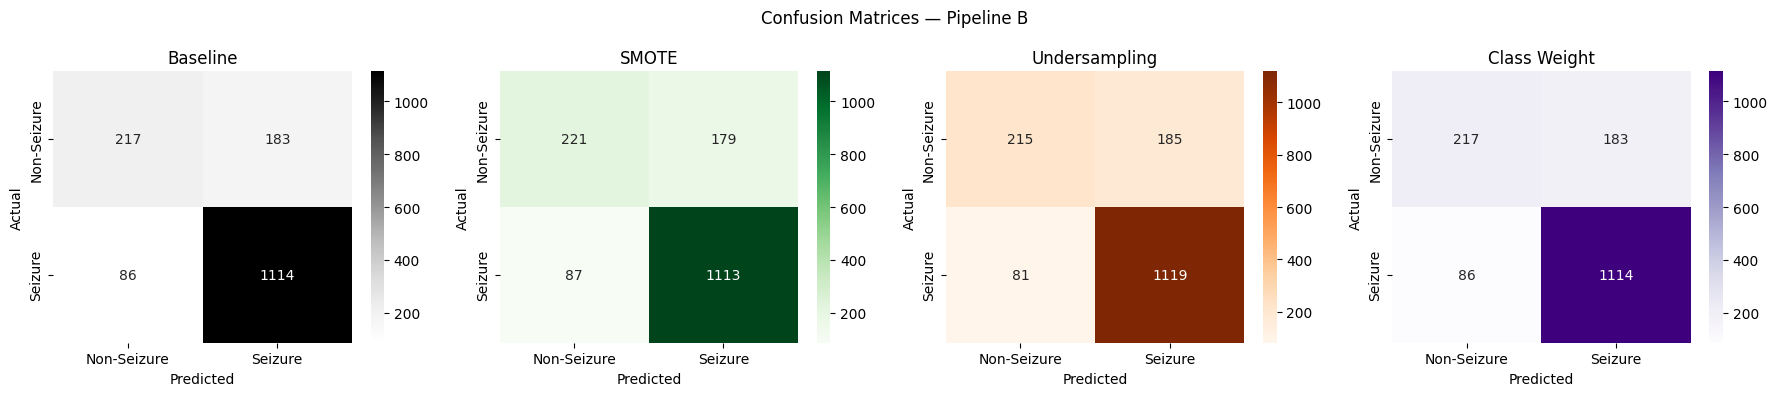

In [225]:
labels_cls = ['Non-Seizure', 'Seizure']
cmaps_all  = ['Greys', 'Greens', 'Oranges', 'Purples']
for pipe, X_te in [('A', X_A_test), ('B', X_B_test)]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, tech, cmap in zip(axes, techniques, cmaps_all):
        cm = confusion_matrix(y_test, imb_trained[f'{tech}_{pipe}'].predict(X_te))
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                    xticklabels=labels_cls, yticklabels=labels_cls)
        ax.set_title(tech); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'Confusion Matrices — Pipeline {pipe}')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/beed_16_cm_pipeline_{pipe}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Final Results Summary

In [226]:
cols = ['Technique', 'Pipeline', 'Accuracy', 'F1', 'PR-AUC']

print('=== Final Results — Class Imbalance Handling ===')
print(imb_df[cols].to_string(index=False))

print('\n=== Best Technique per Pipeline ===')

for pipe in ['Pipeline A', 'Pipeline B']:

    subset = imb_df[imb_df['Pipeline'] == pipe]

    # Best based on F1 Score
    best_f1 = subset.loc[subset['F1'].idxmax()]

    # Best based on Accuracy
    best_acc = subset.loc[subset['Accuracy'].idxmax()]

    print(f'\n{pipe}')
    print(f'Best by F1 Score  → {best_f1["Technique"]:15} | F1: {best_f1["F1"]:.4f} | Accuracy: {best_f1["Accuracy"]:.4f}')
    print(f'Best by Accuracy → {best_acc["Technique"]:15} | Accuracy: {best_acc["Accuracy"]:.4f} | F1: {best_acc["F1"]:.4f}')

=== Final Results — Class Imbalance Handling ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.6687 0.7613  0.7462
     Baseline Pipeline B    0.8319 0.8923  0.7257
        SMOTE Pipeline A    0.6750 0.7656  0.7464
        SMOTE Pipeline B    0.8337 0.8933  0.7272
Undersampling Pipeline A    0.6431 0.7387  0.7475
Undersampling Pipeline B    0.8337 0.8938  0.7253
 Class Weight Pipeline A    0.6687 0.7613  0.7462
 Class Weight Pipeline B    0.8319 0.8923  0.7257

=== Best Technique per Pipeline ===

Pipeline A
Best by F1 Score  → SMOTE           | F1: 0.7656 | Accuracy: 0.6750
Best by Accuracy → SMOTE           | Accuracy: 0.6750 | F1: 0.7656

Pipeline B
Best by F1 Score  → Undersampling   | F1: 0.8938 | Accuracy: 0.8337
Best by Accuracy → SMOTE           | Accuracy: 0.8337 | F1: 0.8933


---
# **Dataset 2: Epileptic Seizure Recognition**

## **Step 1: Setup & Data Loading**

## Data Loading

In [227]:
df2 = pd.read_csv('/content/drive/MyDrive/MS DS/Data Mining/Epileptic Seizure Recognition.csv')

# Drop the sample ID column (not a feature)
df2 = df2.drop(columns=['Unnamed'])

# Binarize: class 1 = Seizure, classes 2,3,4,5 = Non-Seizure
df2['y'] = df2['y'].apply(lambda x: 1 if x == 1 else 0)

print(f'Shape: {df2.shape}')
print(f'Non-Seizure: {(df2["y"]==0).sum()} | Seizure: {(df2["y"]==1).sum()}')
df2.head()

Shape: (11500, 179)
Non-Seizure: 9200 | Seizure: 2300


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


## Descriptive Statistics

=== Descriptive Statistics ===
        count       mean         std     min   25%  50%   75%     max
X1    11500.0 -11.581391  165.626284 -1839.0 -54.0 -8.0  34.0  1726.0
X2    11500.0 -10.911565  166.059609 -1838.0 -55.0 -8.0  35.0  1713.0
X3    11500.0 -10.187130  163.524317 -1835.0 -54.0 -7.0  36.0  1697.0
X4    11500.0  -9.143043  161.269041 -1845.0 -54.0 -8.0  36.0  1612.0
X5    11500.0  -8.009739  160.998007 -1791.0 -54.0 -8.0  35.0  1518.0
...       ...        ...         ...     ...   ...  ...   ...     ...
X175  11500.0 -13.045043  164.241019 -1863.0 -56.0 -9.0  34.0  1958.0
X176  11500.0 -12.705130  162.895832 -1781.0 -55.0 -9.0  34.0  2047.0
X177  11500.0 -12.426000  162.886311 -1727.0 -55.0 -9.0  34.0  2047.0
X178  11500.0 -12.195652  164.852015 -1829.0 -55.0 -9.0  34.0  1915.0
y     11500.0   0.200000    0.400017     0.0   0.0  0.0   0.0     1.0

[179 rows x 8 columns]


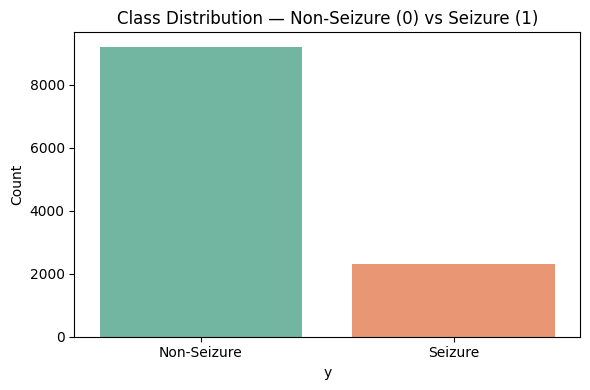

In [228]:
print('=== Descriptive Statistics ===')
print(df2.describe().T)

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df2, palette='Set2')
plt.title('Class Distribution — Non-Seizure (0) vs Seizure (1)')
plt.xticks([0, 1], ['Non-Seizure', 'Seizure'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Missing Value Check

In [229]:
missing2 = df2.isnull().sum()
pct2     = (missing2 / len(df2) * 100).round(2)
print(f'Total missing values: {missing2.sum()}')
if missing2.sum() == 0:
    print('No missing values. Dataset is complete.')

Total missing values: 0
No missing values. Dataset is complete.


## **Step 2: Preprocessing Pipelines**

## Train/Test Split

In [230]:
X2 = df2.drop(columns=['y'])
y2 = df2['y']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
print(f'Train: {X2_train.shape} | Test: {X2_test.shape}')
print(f'Train class distribution:\n{y2_train.value_counts()}')

Train: (9200, 178) | Test: (2300, 178)
Train class distribution:
y
0    7360
1    1840
Name: count, dtype: int64


## Pipeline A — Step 1: Outlier Clipping (IQR)

In [231]:
Q1_2, Q3_2 = X2_train.quantile(0.25), X2_train.quantile(0.75)
IQR2       = Q3_2 - Q1_2
lower2, upper2 = Q1_2 - 1.5 * IQR2, Q3_2 + 1.5 * IQR2

X2_A_tr = X2_train.clip(lower=lower2, upper=upper2, axis=1)
X2_A_te = X2_test.clip(lower=lower2,  upper=upper2, axis=1)
print(f'IQR Clipping done. Range: [{X2_A_tr.min().min():.2f}, {X2_A_tr.max().max():.2f}]')

IQR Clipping done. Range: [-195.50, 177.00]


## Pipeline A — Step 2: MinMax Normalization

In [232]:
scaler2_A = MinMaxScaler()
X2_A_tr   = pd.DataFrame(scaler2_A.fit_transform(X2_A_tr), columns=X2_train.columns)
X2_A_te   = pd.DataFrame(scaler2_A.transform(X2_A_te),     columns=X2_train.columns)
print(f'MinMax Scaling done. Range: [{X2_A_tr.min().min():.2f}, {X2_A_tr.max().max():.2f}]')

MinMax Scaling done. Range: [0.00, 1.00]


## Pipeline A — Step 3: ANOVA Feature Selection

Feature Selection done. Selected 20 of 178 features.
Selected: ['X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X34', 'X35', 'X36', 'X37', 'X42', 'X43', 'X44', 'X45', 'X46', 'X95', 'X102', 'X103', 'X158', 'X159']


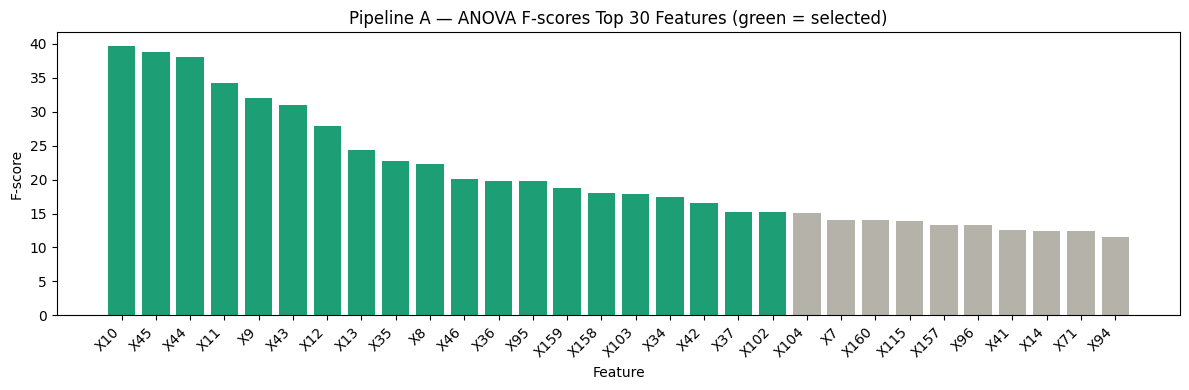

In [233]:
# k=20 because UCI has 178 features — keeping 20 gives a richer feature set
selector2  = SelectKBest(f_classif, k=20)
X2_A_train = pd.DataFrame(selector2.fit_transform(X2_A_tr, y2_train),
                           columns=X2_train.columns[selector2.get_support()])
X2_A_test  = pd.DataFrame(selector2.transform(X2_A_te),
                           columns=X2_train.columns[selector2.get_support()])

selected2 = X2_A_train.columns.tolist()
print(f'Feature Selection done. Selected 20 of 178 features.')
print(f'Selected: {selected2}')

# Top 30 features bar chart (178 bars too dense, show top 30)
all_scores2 = pd.Series(selector2.scores_, index=X2_train.columns).sort_values(ascending=False)
top30       = all_scores2.head(30)
colors2     = ['#1D9E75' if f in selected2 else '#B4B2A9' for f in top30.index]
plt.figure(figsize=(12, 4))
plt.bar(top30.index, top30.values, color=colors2)
plt.title('Pipeline A — ANOVA F-scores Top 30 Features (green = selected)')
plt.xlabel('Feature'); plt.ylabel('F-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_04_pipeline_A_anova.png', dpi=150, bbox_inches='tight')
plt.show()

## Pipeline B — Step 1: Z-score Standardization

In [234]:
# Extract 6 statistical features from 178 raw time-steps BEFORE scaling
# This is the key fix — raw time-steps have poor class separation in PCA
def extract_ts_features(X):
    X = X.values if hasattr(X, 'values') else X
    return np.column_stack([
        np.mean(X, axis=1),
        np.std(X, axis=1),
        np.max(X, axis=1) - np.min(X, axis=1),
        np.percentile(X, 75, axis=1) - np.percentile(X, 25, axis=1),
        np.mean(np.abs(np.diff(X, axis=1)), axis=1),
        np.sum(X**2, axis=1) / X.shape[1],
    ])

X2_B_tr = extract_ts_features(X2_train)
X2_B_te = extract_ts_features(X2_test)

scaler2_B = StandardScaler()
X2_B_tr = scaler2_B.fit_transform(X2_B_tr)
X2_B_te = scaler2_B.transform(X2_B_te)

print(f'Features after extraction: {X2_B_tr.shape[1]}  (mean, std, range, IQR, activity, energy)')

Features after extraction: 6  (mean, std, range, IQR, activity, energy)


## Pipeline B — Step 2: PCA

In [235]:
pca2 = PCA(n_components=0.95, random_state=42)
pca2.fit(X2_B_tr)
pc_cols2 = [f'PC{i+1}' for i in range(pca2.n_components_)]
X2_B_train = pd.DataFrame(pca2.transform(X2_B_tr), columns=pc_cols2)
X2_B_test  = pd.DataFrame(pca2.transform(X2_B_te), columns=pc_cols2)
cum_var2 = np.cumsum(pca2.explained_variance_ratio_)
print(f'PCA done. Components: {pca2.n_components_}, Variance retained: {cum_var2[-1]*100:.2f}%')

PCA done. Components: 2, Variance retained: 95.57%


## **Step 3: Baseline Logistic Regression**

## Train Baseline Model

In [236]:
lr2_A = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2_B = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2_A.fit(X2_A_train, y2_train)
lr2_B.fit(X2_B_train, y2_train)

def get_metrics2(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    p, r, _ = precision_recall_curve(y_te, y_prob)
    pr_auc   = auc(r, p)
    print(f'{name} → Accuracy: {acc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f}')
    return {'name': name, 'accuracy': acc, 'f1': f1, 'pr_auc': pr_auc}

print('=== Baseline Results ===')
res2_A = get_metrics2(lr2_A, X2_A_test, y2_test, 'Pipeline A')
res2_B = get_metrics2(lr2_B, X2_B_test, y2_test, 'Pipeline B')

=== Baseline Results ===
Pipeline A → Accuracy: 0.5374 | F1: 0.2840 | PR-AUC: 0.3706
Pipeline B → Accuracy: 0.9517 | F1: 0.8857 | PR-AUC: 0.9550


## Classification Report

In [237]:
labels = ['Non-Seizure', 'Seizure']
print('=== Pipeline A — Classification Report ===')
print(classification_report(y2_test, lr2_A.predict(X2_A_test), target_names=labels))
print('=== Pipeline B — Classification Report ===')
print(classification_report(y2_test, lr2_B.predict(X2_B_test), target_names=labels))

=== Pipeline A — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.80      0.56      0.66      1840
     Seizure       0.21      0.46      0.28       460

    accuracy                           0.54      2300
   macro avg       0.51      0.51      0.47      2300
weighted avg       0.68      0.54      0.58      2300

=== Pipeline B — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.98      0.96      0.97      1840
     Seizure       0.84      0.93      0.89       460

    accuracy                           0.95      2300
   macro avg       0.91      0.95      0.93      2300
weighted avg       0.95      0.95      0.95      2300



## Confusion Matrix

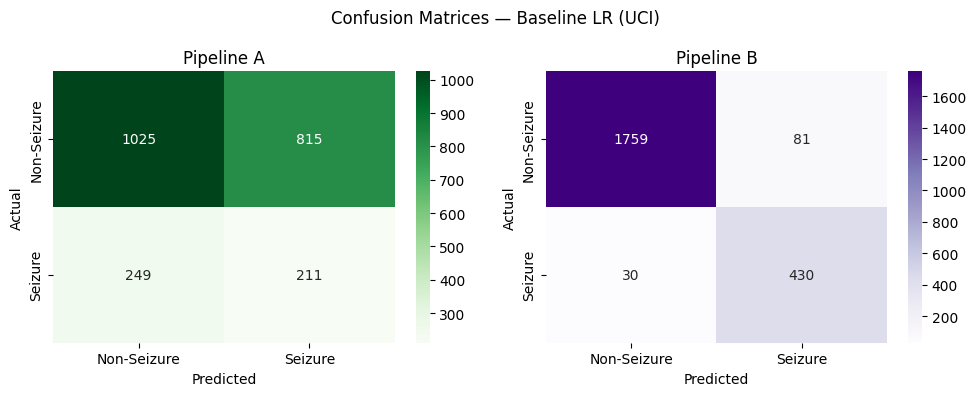

In [238]:
labels = ['Non-Seizure', 'Seizure']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, X_te, title, cmap in zip(
    axes, [lr2_A, lr2_B], [X2_A_test, X2_B_test],
    ['Pipeline A', 'Pipeline B'], ['Greens', 'Purples']
):
    cm = confusion_matrix(y2_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Baseline LR (UCI)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_06_baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Baseline Results Comparison

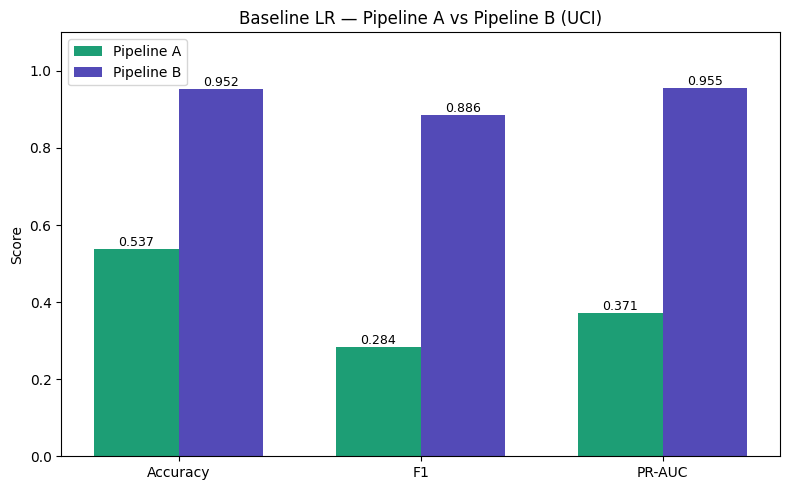

In [239]:
metrics_keys   = ['accuracy', 'f1', 'pr_auc']
metrics_labels = ['Accuracy', 'F1', 'PR-AUC']
x = np.arange(len(metrics_keys)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [res2_A[m] for m in metrics_keys], w, label='Pipeline A', color='#1D9E75')
ax.bar(x + w/2, [res2_B[m] for m in metrics_keys], w, label='Pipeline B', color='#534AB7')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Baseline LR — Pipeline A vs Pipeline B (UCI)')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_07_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 4: Overfitting & Underfitting**

## Underfitting Scenario

In [240]:
X2_u_tr = X2_A_train.iloc[:, :2]
X2_u_te = X2_A_test.iloc[:, :2]

lr2_under = LogisticRegression(C=0.0001, max_iter=1000, random_state=42)
lr2_under.fit(X2_u_tr, y2_train)

tr_acc = lr2_under.score(X2_u_tr, y2_train)
te_acc = lr2_under.score(X2_u_te, y2_test)
print('=== Underfitting Scenario ===')
print(f'Features used  : {X2_u_tr.columns.tolist()}')
print(f'C              : 0.0001 (very strong regularization)')
print(f'Train Accuracy : {tr_acc:.4f}')
print(f'Test  Accuracy : {te_acc:.4f}')
print(f'Gap            : {tr_acc - te_acc:.4f}')
print('Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)')

=== Underfitting Scenario ===
Features used  : ['X8', 'X9']
C              : 0.0001 (very strong regularization)
Train Accuracy : 0.8000
Test  Accuracy : 0.8000
Gap            : 0.0000
Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)


## Overfitting Scenario

In [241]:
# degree=2 only — 20 features with degree=3 would be too slow
poly2   = PolynomialFeatures(degree=2, include_bias=False)
X2_o_tr = poly2.fit_transform(X2_A_train)
X2_o_te = poly2.transform(X2_A_test)

lr2_over = LogisticRegression(C=10000, max_iter=1000, random_state=42, class_weight='balanced')
lr2_over.fit(X2_o_tr, y2_train)

tr_acc = lr2_over.score(X2_o_tr, y2_train)
te_acc = lr2_over.score(X2_o_te, y2_test)
print('=== Overfitting Scenario ===')
print(f'Features after polynomial expansion : {X2_o_tr.shape[1]}')
print(f'C                                   : 10000 (minimal regularization)')
print(f'Train Accuracy                      : {tr_acc:.4f}')
print(f'Test  Accuracy                      : {te_acc:.4f}')
print(f'Gap                                 : {tr_acc - te_acc:.4f}')
print('NOTE: Small gap expected — LR is structurally resistant to overfitting.')

=== Overfitting Scenario ===
Features after polynomial expansion : 230
C                                   : 10000 (minimal regularization)
Train Accuracy                      : 0.9495
Test  Accuracy                      : 0.9313
Gap                                 : 0.0182
NOTE: Small gap expected — LR is structurally resistant to overfitting.


## Validation Curve

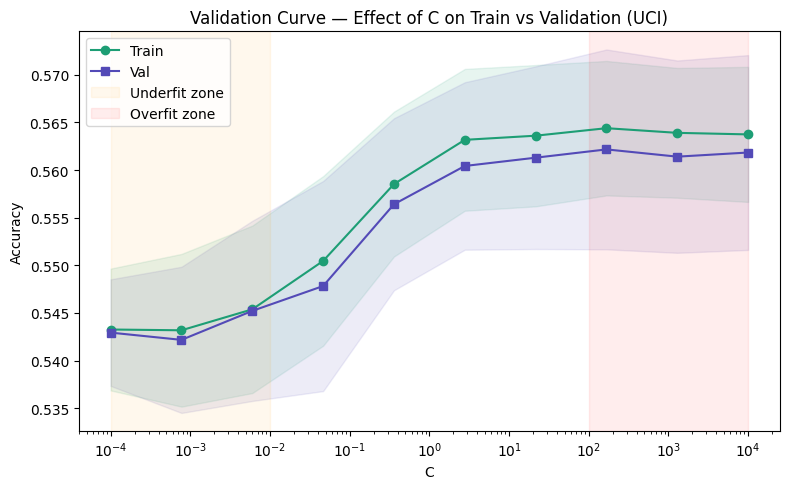

In [242]:
C_range2 = np.logspace(-4, 4, 10)
tr_scores2, val_scores2 = validation_curve(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X2_A_train, y2_train, param_name='C', param_range=C_range2,
    cv=5, scoring='accuracy', n_jobs=-1
)
tr_mean2, tr_std2 = tr_scores2.mean(axis=1), tr_scores2.std(axis=1)
v_mean2,  v_std2  = val_scores2.mean(axis=1), val_scores2.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(C_range2, tr_mean2, label='Train', color='#1D9E75', marker='o')
plt.semilogx(C_range2, v_mean2,  label='Val',   color='#534AB7', marker='s')
plt.fill_between(C_range2, tr_mean2-tr_std2, tr_mean2+tr_std2, alpha=0.1, color='#1D9E75')
plt.fill_between(C_range2, v_mean2-v_std2,   v_mean2+v_std2,   alpha=0.1, color='#534AB7')
plt.axvspan(1e-4, 1e-2, alpha=0.07, color='orange', label='Underfit zone')
plt.axvspan(1e2,  1e4,  alpha=0.07, color='red',    label='Overfit zone')
plt.xlabel('C'); plt.ylabel('Accuracy')
plt.title('Validation Curve — Effect of C on Train vs Validation (UCI)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_08_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Curves

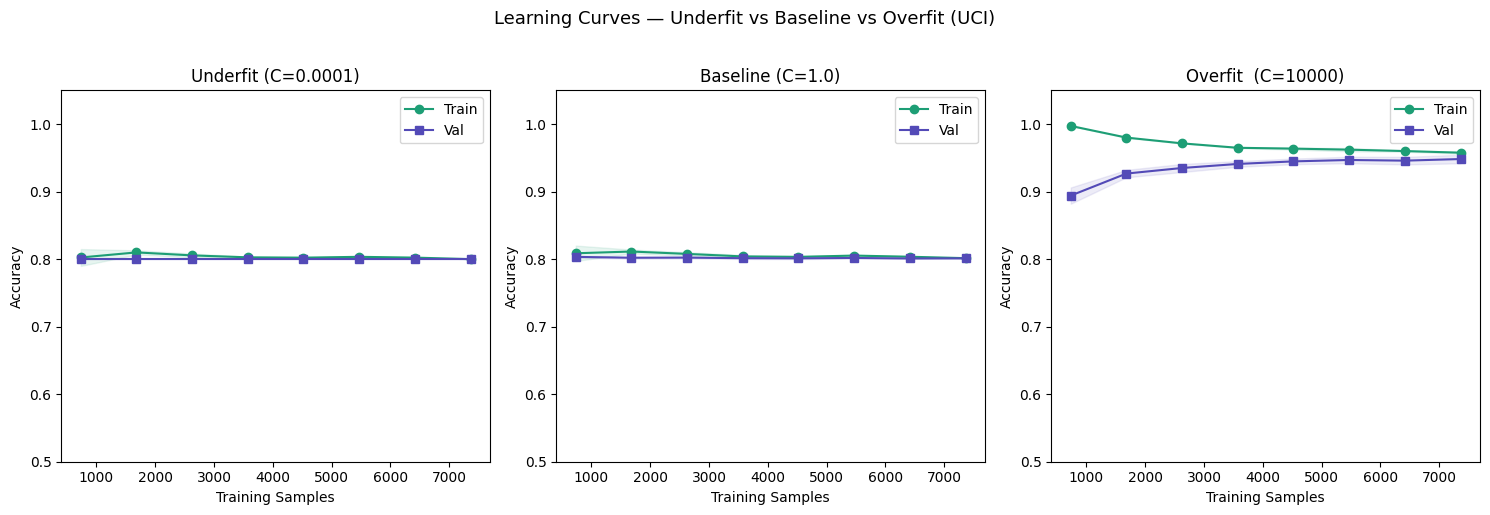

In [243]:
train_sizes2 = np.linspace(0.1, 1.0, 8)
scenarios2   = [
    ('Underfit (C=0.0001)', LogisticRegression(C=0.0001, max_iter=1000, random_state=42), X2_u_tr, y2_train),
    ('Baseline (C=1.0)',    LogisticRegression(C=1.0,    max_iter=1000, random_state=42), X2_A_train, y2_train),
    ('Overfit  (C=10000)',  LogisticRegression(C=10000,  max_iter=1000, random_state=42), X2_o_tr, y2_train),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, model, X_lc, y_lc) in zip(axes, scenarios2):
    sizes, tr_s, v_s = learning_curve(
        model, X_lc, y_lc, train_sizes=train_sizes2, cv=5, scoring='accuracy', n_jobs=-1
    )
    ax.plot(sizes, tr_s.mean(axis=1), label='Train', color='#1D9E75', marker='o')
    ax.plot(sizes, v_s.mean(axis=1),  label='Val',   color='#534AB7', marker='s')
    ax.fill_between(sizes, tr_s.mean(axis=1)-tr_s.std(axis=1),
                           tr_s.mean(axis=1)+tr_s.std(axis=1), alpha=0.1, color='#1D9E75')
    ax.fill_between(sizes, v_s.mean(axis=1)-v_s.std(axis=1),
                           v_s.mean(axis=1)+v_s.std(axis=1),   alpha=0.1, color='#534AB7')
    ax.set_title(label); ax.set_xlabel('Training Samples'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.set_ylim(0.5, 1.05)
plt.suptitle('Learning Curves — Underfit vs Baseline vs Overfit (UCI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_09_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting & Underfitting Results Summary

In [244]:
summary_ou2 = pd.DataFrame([
    {'Scenario': 'Underfitting', 'C': 0.0001, 'Features': 2,
     'Train Acc': round(lr2_under.score(X2_u_tr, y2_train), 4),
     'Test Acc' : round(lr2_under.score(X2_u_te, y2_test),  4)},
    {'Scenario': 'Baseline',    'C': 1.0,    'Features': X2_A_train.shape[1],
     'Train Acc': round(lr2_A.score(X2_A_train, y2_train),  4),
     'Test Acc' : round(lr2_A.score(X2_A_test,  y2_test),   4)},
    {'Scenario': 'Overfitting', 'C': 10000,  'Features': X2_o_tr.shape[1],
     'Train Acc': round(lr2_over.score(X2_o_tr, y2_train),  4),
     'Test Acc' : round(lr2_over.score(X2_o_te, y2_test),   4)},
])
summary_ou2['Gap'] = (summary_ou2['Train Acc'] - summary_ou2['Test Acc']).round(4)
print('=== Overfitting / Underfitting Results Summary (UCI) ===')
summary_ou2

=== Overfitting / Underfitting Results Summary (UCI) ===


,Scenario,C,Features,Train Acc,Test Acc,Gap
0,Underfitting,0.0001,2,0.8000,0.8000,0.0000
1,Baseline,1.0000,20,0.5593,0.5374,0.0219
2,Overfitting,10000.0000,230,0.9495,0.9313,0.0182


## **Step 5: Regularization Study**

## Train L1, L2 and ElasticNet

In [245]:
reg_configs2 = {
    'L1 (Lasso)': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000, random_state=42, class_weight='balanced'),
    'L2 (Ridge)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',     max_iter=1000, random_state=42, class_weight='balanced'),
    'ElasticNet' : SGDClassifier(loss='modified_huber', penalty='elasticnet',
                                 l1_ratio=0.5, alpha=0.001, max_iter=1000, random_state=42, class_weight='balanced'),
}

trained2_A, trained2_B, reg_rows2 = {}, {}, []
for name, model in reg_configs2.items():
    m_A = copy.deepcopy(model); m_A.fit(X2_A_train, y2_train); trained2_A[name] = m_A
    m_B = copy.deepcopy(model); m_B.fit(X2_B_train, y2_train); trained2_B[name] = m_B
    for pipe, m, X_te in [('Pipeline A', m_A, X2_A_test), ('Pipeline B', m_B, X2_B_test)]:
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y2_test, y_prob)
        reg_rows2.append({'Regularizer': name, 'Pipeline': pipe,
                          'Accuracy': round(accuracy_score(y2_test, y_pred), 4),
                          'F1':       round(f1_score(y2_test, y_pred), 4),
                          'PR-AUC':   round(auc(r, p), 4)})

reg_metrics2_df = pd.DataFrame(reg_rows2)
print('=== Regularization Metrics (UCI) ===')
print(reg_metrics2_df.to_string(index=False))

=== Regularization Metrics (UCI) ===
Regularizer   Pipeline  Accuracy     F1  PR-AUC
 L1 (Lasso) Pipeline A    0.5404 0.2930  0.3681
 L1 (Lasso) Pipeline B    0.9517 0.8857  0.9550
 L2 (Ridge) Pipeline A    0.5374 0.2840  0.3706
 L2 (Ridge) Pipeline B    0.9517 0.8857  0.9550
 ElasticNet Pipeline A    0.8204 0.2103  0.3767
 ElasticNet Pipeline B    0.9517 0.8850  0.9497


## Coefficient Sparsity Analysis

=== Sparsity Analysis (Pipeline A — UCI) ===
  L1 (Lasso)      → Zero coefficients: 2/20 | Sparsity: 10.0%
  L2 (Ridge)      → Zero coefficients: 0/20 | Sparsity: 0.0%
  ElasticNet      → Zero coefficients: 5/20 | Sparsity: 25.0%


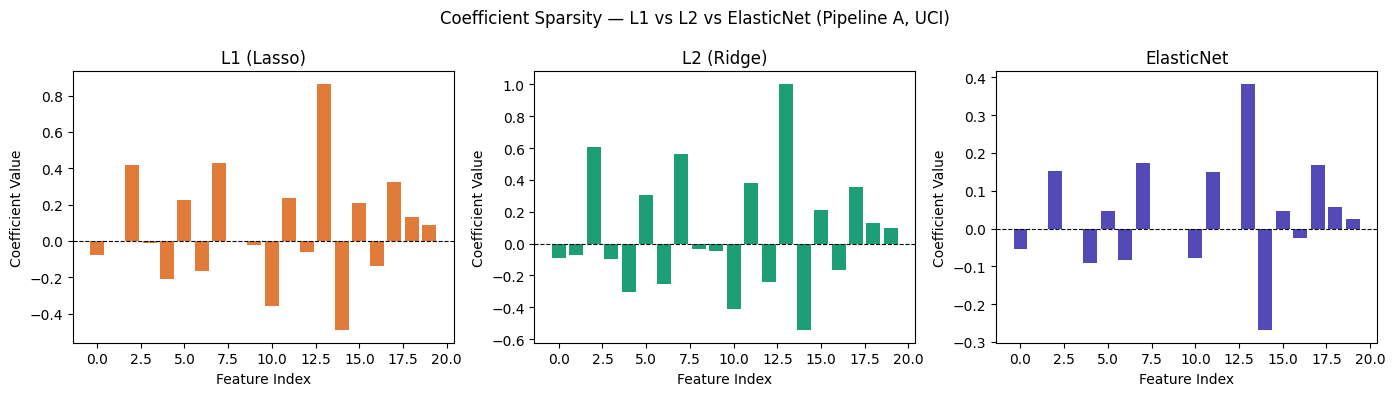

In [246]:
print('=== Sparsity Analysis (Pipeline A — UCI) ===')
for name, model in trained2_A.items():
    if hasattr(model, 'coef_'):
        coefs = model.coef_.flatten()
        zeros = (np.abs(coefs) < 1e-4).sum()
        print(f'  {name:15} → Zero coefficients: {zeros}/{len(coefs)} | Sparsity: {zeros/len(coefs)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model), color in zip(axes, trained2_A.items(), ['#E07B39', '#1D9E75', '#534AB7']):
    coefs = model.coef_.flatten()
    ax.bar(range(len(coefs)), coefs, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(name); ax.set_xlabel('Feature Index'); ax.set_ylabel('Coefficient Value')
plt.suptitle('Coefficient Sparsity — L1 vs L2 vs ElasticNet (Pipeline A, UCI)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_10_coefficient_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Path — L1 vs L2

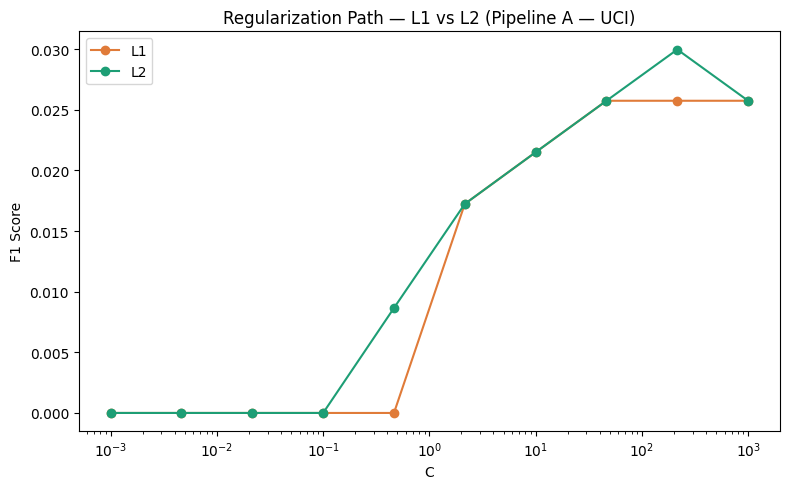

In [247]:
C_range2p = np.logspace(-3, 3, 10)
plt.figure(figsize=(8, 5))
for penalty, solver, color, label in [
    ('l1', 'liblinear', '#E07B39', 'L1'),
    ('l2', 'lbfgs',     '#1D9E75', 'L2'),
]:
    f1s = []
    for C in C_range2p:
        m = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=1000, random_state=42)
        m.fit(X2_A_train, y2_train)
        f1s.append(f1_score(y2_test, m.predict(X2_A_test)))
    plt.semilogx(C_range2p, f1s, marker='o', color=color, label=label)
plt.xlabel('C'); plt.ylabel('F1 Score')
plt.title('Regularization Path — L1 vs L2 (Pipeline A — UCI)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_12_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Results Summary

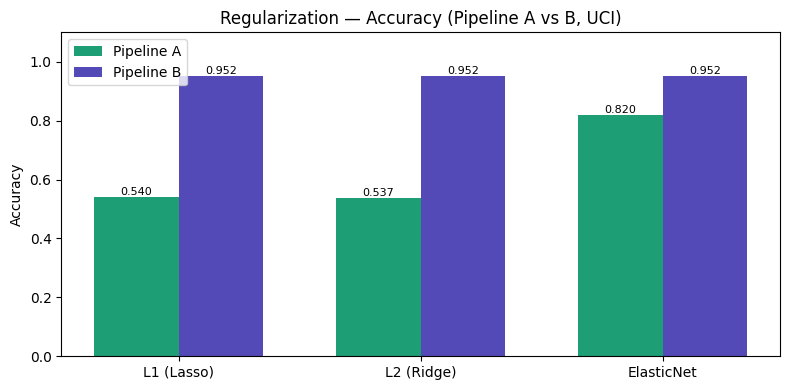

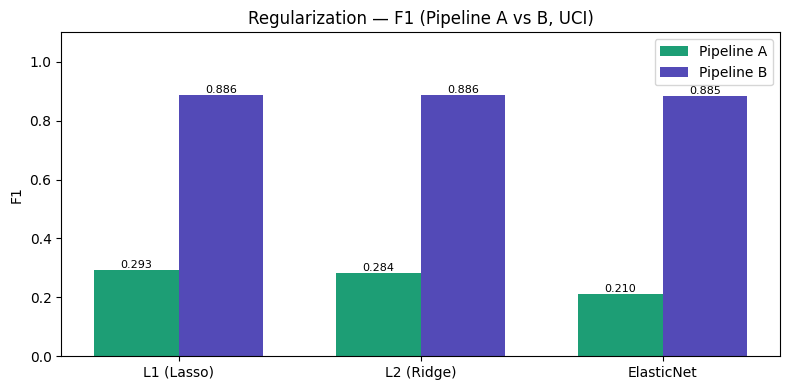

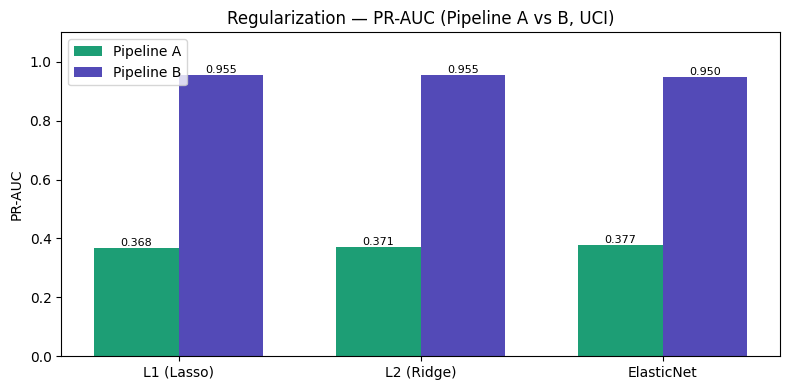

In [248]:
reg_names2 = reg_metrics2_df['Regularizer'].unique().tolist()
x2 = np.arange(len(reg_names2)); w2 = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [reg_metrics2_df[(reg_metrics2_df.Regularizer==n) & (reg_metrics2_df.Pipeline=='Pipeline A')][metric].values[0] for n in reg_names2]
    vals_B = [reg_metrics2_df[(reg_metrics2_df.Regularizer==n) & (reg_metrics2_df.Pipeline=='Pipeline B')][metric].values[0] for n in reg_names2]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x2 - w2/2, vals_A, w2, label='Pipeline A', color='#1D9E75')
    ax.bar(x2 + w2/2, vals_B, w2, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x2); ax.set_xticklabels(reg_names2)
    ax.set_ylim(0, 1.1); ax.set_ylabel(metric)
    ax.set_title(f'Regularization — {metric} (Pipeline A vs B, UCI)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/uci_13_reg_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Step 6: Class Imbalance Handling**

## Apply Sampling Techniques

In [249]:
smote2 = SMOTE(random_state=42)
rus2   = RandomUnderSampler(random_state=42)

X2_smote_A, y2_smote_A = smote2.fit_resample(X2_A_train, y2_train)
X2_under_A, y2_under_A = rus2.fit_resample(X2_A_train,   y2_train)
X2_smote_B, y2_smote_B = smote2.fit_resample(X2_B_train, y2_train)
X2_under_B, y2_under_B = rus2.fit_resample(X2_B_train,   y2_train)

configs2 = {
    'Baseline'     : {'A': (X2_A_train, y2_train),   'B': (X2_B_train, y2_train),   'cw': 'balanced'},
    'SMOTE'        : {'A': (X2_smote_A, y2_smote_A), 'B': (X2_smote_B, y2_smote_B), 'cw': None},
    'Undersampling': {'A': (X2_under_A, y2_under_A), 'B': (X2_under_B, y2_under_B), 'cw': None},
    'Class Weight' : {'A': (X2_A_train, y2_train),   'B': (X2_B_train, y2_train),   'cw': 'balanced'},
}

imb2_trained, imb2_rows = {}, []
for name, data in configs2.items():
    for pipe, X_te in [('A', X2_A_test), ('B', X2_B_test)]:
        X_tr, y_tr = data[pipe]
        m = LogisticRegression(class_weight=data['cw'], max_iter=1000, random_state=42)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y2_test, y_prob)
        imb2_rows.append({
            'Technique': name, 'Pipeline': f'Pipeline {pipe}',
            'Accuracy' : round(accuracy_score(y2_test, y_pred), 4),
            'F1'       : round(f1_score(y2_test, y_pred), 4),
            'PR-AUC'   : round(auc(r, p), 4),
        })
        imb2_trained[f'{name}_{pipe}'] = m

imb2_df = pd.DataFrame(imb2_rows)
print('=== Imbalance Handling Results (UCI Epileptic) ===')
print(imb2_df.to_string(index=False))

=== Imbalance Handling Results (UCI Epileptic) ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.5374 0.2840  0.3706
     Baseline Pipeline B    0.9517 0.8857  0.9550
        SMOTE Pipeline A    0.5543 0.2955  0.3749
        SMOTE Pipeline B    0.9513 0.8841  0.9550
Undersampling Pipeline A    0.5313 0.2851  0.3603
Undersampling Pipeline B    0.9504 0.8830  0.9550
 Class Weight Pipeline A    0.5374 0.2840  0.3706
 Class Weight Pipeline B    0.9517 0.8857  0.9550


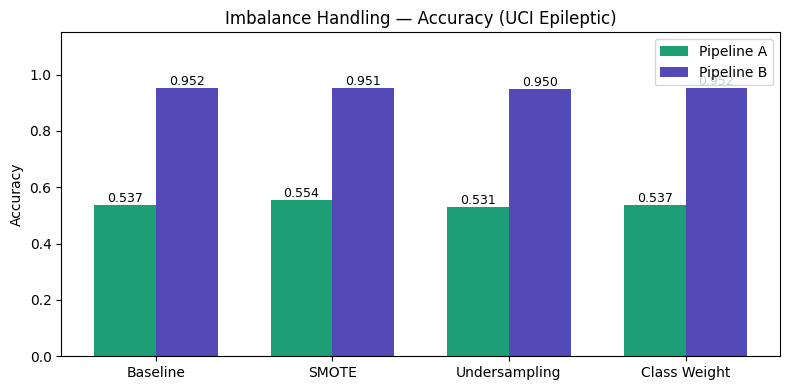

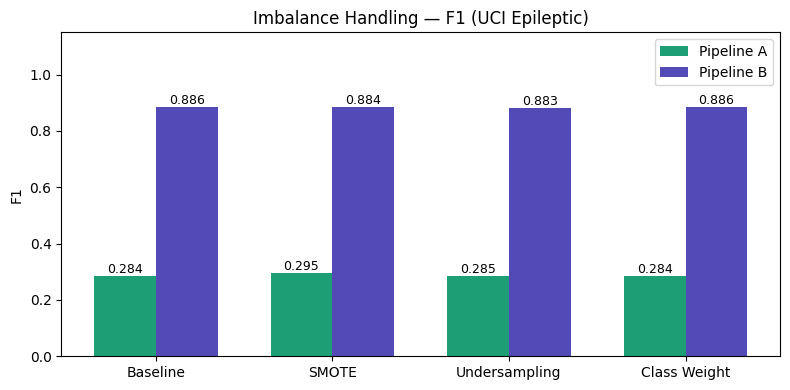

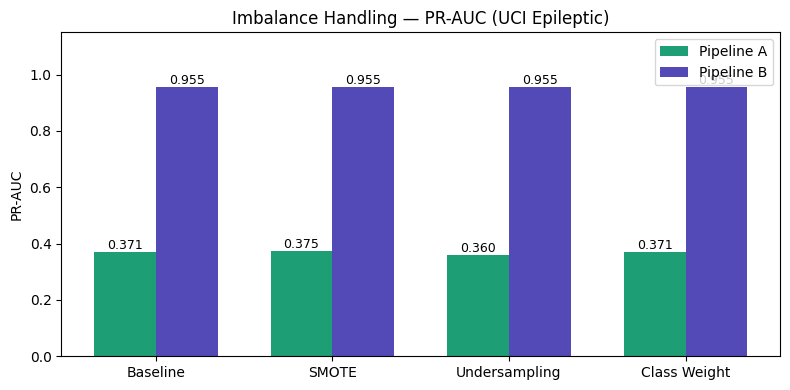

In [250]:
techniques2 = list(configs2.keys())
x = np.arange(len(techniques2)); w = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [imb2_df[(imb2_df.Technique==t) & (imb2_df.Pipeline=='Pipeline A')][metric].values[0] for t in techniques2]
    vals_B = [imb2_df[(imb2_df.Technique==t) & (imb2_df.Pipeline=='Pipeline B')][metric].values[0] for t in techniques2]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, vals_A, w, label='Pipeline A', color='#1D9E75')
    ax.bar(x + w/2, vals_B, w, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x); ax.set_xticklabels(techniques2)
    ax.set_ylim(0, 1.15); ax.set_ylabel(metric)
    ax.set_title(f'Imbalance Handling — {metric} (UCI Epileptic)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/uci_imbalance_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Precision-Recall Curves

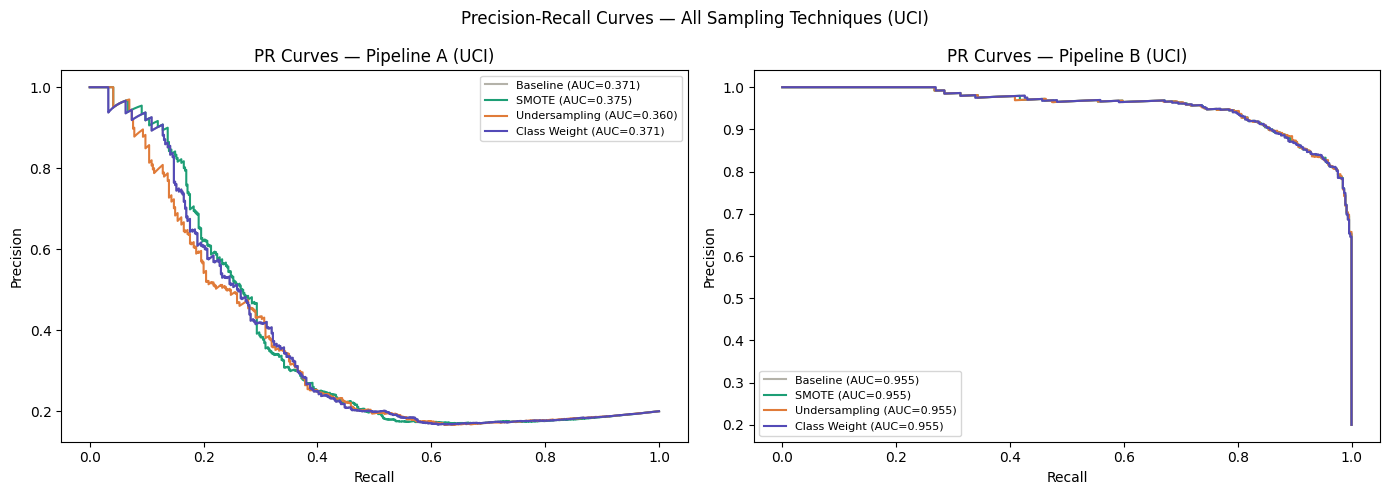

In [251]:
techniques2  = imb2_df['Technique'].unique().tolist()
colors_tech2 = ['#B4B2A9', '#1D9E75', '#E07B39', '#534AB7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pipe, X_te) in zip(axes, [('A', X2_A_test), ('B', X2_B_test)]):
    for tech, color in zip(techniques2, colors_tech2):
        y_prob = imb2_trained[f'{tech}_{pipe}'].predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y2_test, y_prob)
        ax.plot(r, p, color=color, label=f'{tech} (AUC={auc(r,p):.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — Pipeline {pipe} (UCI)'); ax.legend(fontsize=8)
plt.suptitle('Precision-Recall Curves — All Sampling Techniques (UCI)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uci_14_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Reports

In [252]:
labels_cls = ['Non-Seizure', 'Seizure']
for pipe, X_te in [('A', X2_A_test), ('B', X2_B_test)]:
    print(f'\n{"="*55}')
    print(f'  Pipeline {pipe} — Classification Reports (UCI)')
    print(f'{"="*55}')
    for tech in techniques2:
        y_pred = imb2_trained[f'{tech}_{pipe}'].predict(X_te)
        print(f'\n--- {tech} ---')
        print(classification_report(y2_test, y_pred, target_names=labels_cls))


  Pipeline A — Classification Reports (UCI)

--- Baseline ---
              precision    recall  f1-score   support

 Non-Seizure       0.80      0.56      0.66      1840
     Seizure       0.21      0.46      0.28       460

    accuracy                           0.54      2300
   macro avg       0.51      0.51      0.47      2300
weighted avg       0.68      0.54      0.58      2300


--- SMOTE ---
              precision    recall  f1-score   support

 Non-Seizure       0.81      0.58      0.67      1840
     Seizure       0.22      0.47      0.30       460

    accuracy                           0.55      2300
   macro avg       0.51      0.52      0.48      2300
weighted avg       0.69      0.55      0.60      2300


--- Undersampling ---
              precision    recall  f1-score   support

 Non-Seizure       0.80      0.55      0.65      1840
     Seizure       0.21      0.47      0.29       460

    accuracy                           0.53      2300
   macro avg       0.50    

## Confusion Matrices

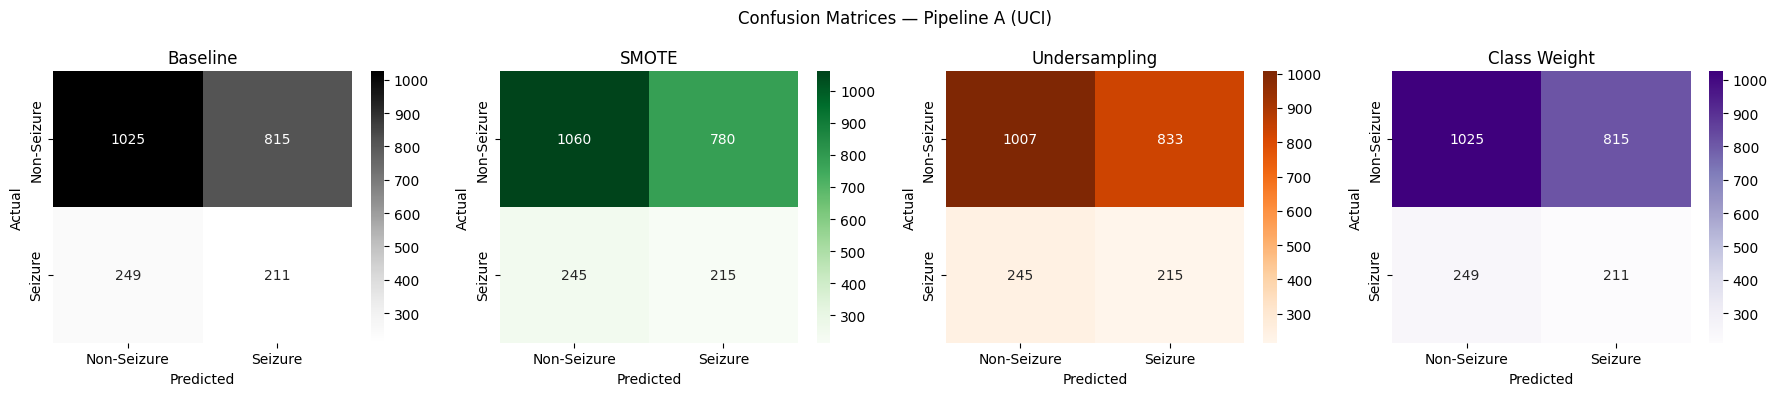

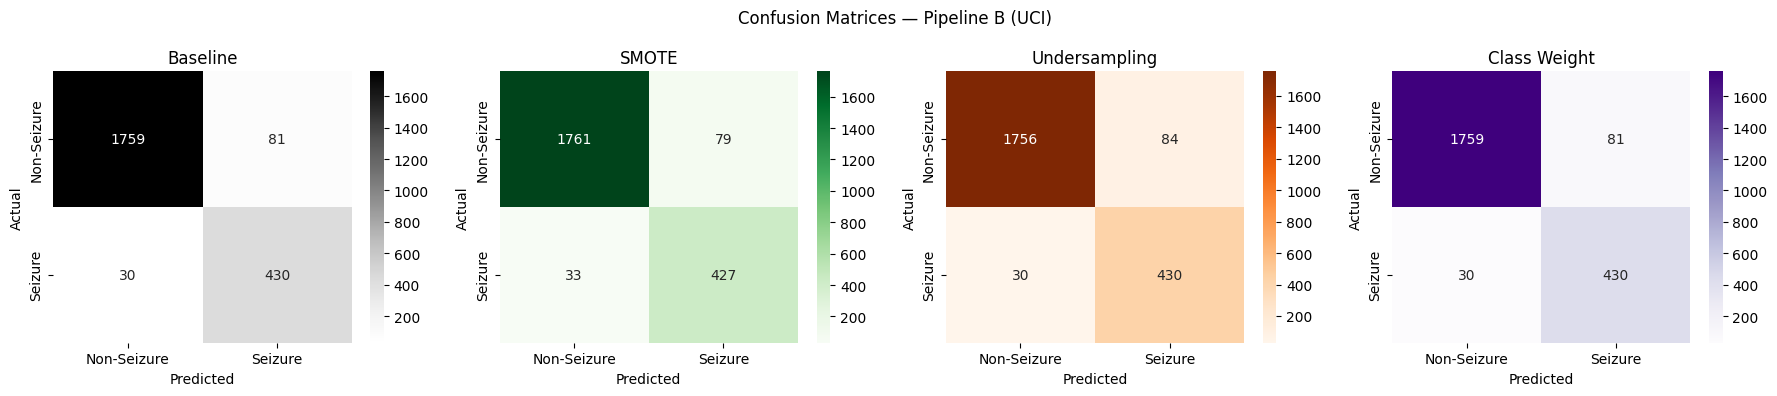

In [253]:
labels_cls = ['Non-Seizure', 'Seizure']
cmaps_all  = ['Greys', 'Greens', 'Oranges', 'Purples']
for pipe, X_te in [('A', X2_A_test), ('B', X2_B_test)]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, tech, cmap in zip(axes, techniques2, cmaps_all):
        cm = confusion_matrix(y2_test, imb2_trained[f'{tech}_{pipe}'].predict(X_te))
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                    xticklabels=labels_cls, yticklabels=labels_cls)
        ax.set_title(tech); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'Confusion Matrices — Pipeline {pipe} (UCI)')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/uci_16_cm_pipeline_{pipe}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Final Results Summary

In [254]:
cols = ['Technique', 'Pipeline', 'Accuracy', 'F1', 'PR-AUC']

print('=== Final Results — Class Imbalance Handling (UCI) ===')
print(imb2_df[cols].to_string(index=False))

print('\n=== Best Technique per Pipeline ===')

for pipe in ['Pipeline A', 'Pipeline B']:

    subset = imb2_df[imb2_df['Pipeline'] == pipe]

    # Best based on F1 Score
    best_f1 = subset.loc[subset['F1'].idxmax()]

    # Best based on Accuracy
    best_acc = subset.loc[subset['Accuracy'].idxmax()]

    print(f'\n{pipe}')
    print(f'Best by F1 Score  → {best_f1["Technique"]:15} | F1: {best_f1["F1"]:.4f} | Accuracy: {best_f1["Accuracy"]:.4f}')
    print(f'Best by Accuracy → {best_acc["Technique"]:15} | Accuracy: {best_acc["Accuracy"]:.4f} | F1: {best_acc["F1"]:.4f}')

=== Final Results — Class Imbalance Handling (UCI) ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.5374 0.2840  0.3706
     Baseline Pipeline B    0.9517 0.8857  0.9550
        SMOTE Pipeline A    0.5543 0.2955  0.3749
        SMOTE Pipeline B    0.9513 0.8841  0.9550
Undersampling Pipeline A    0.5313 0.2851  0.3603
Undersampling Pipeline B    0.9504 0.8830  0.9550
 Class Weight Pipeline A    0.5374 0.2840  0.3706
 Class Weight Pipeline B    0.9517 0.8857  0.9550

=== Best Technique per Pipeline ===

Pipeline A
Best by F1 Score  → SMOTE           | F1: 0.2955 | Accuracy: 0.5543
Best by Accuracy → SMOTE           | Accuracy: 0.5543 | F1: 0.2955

Pipeline B
Best by F1 Score  → Baseline        | F1: 0.8857 | Accuracy: 0.9517
Best by Accuracy → Baseline        | Accuracy: 0.9517 | F1: 0.8857


# **Dataset 3: Bonn EEG Dataset**

## Data Loading

In [255]:
df3 = pd.read_csv('/content/drive/MyDrive/MS DS/Data Mining/bonn_eeg.csv')

# Original classes: S = Seizure (ictal), F/O/Z = Non-Seizure states
print('Original class distribution:')
print(df3['label'].value_counts())

# Binarize: S -> 1 (Seizure), F/O/Z -> 0 (Non-Seizure)
df3['label'] = df3['label'].apply(lambda x: 1 if x == 'S' else 0)

print(f'\nShape: {df3.shape}')
print(f'Non-Seizure (0): {(df3["label"]==0).sum()} | Seizure (1): {(df3["label"]==1).sum()}')
df3.head()

Original class distribution:
label
F    100
O    100
S    100
Z    100
Name: count, dtype: int64

Shape: (400, 4098)
Non-Seizure (0): 300 | Seizure (1): 100


,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_4088,signal_4089,signal_4090,signal_4091,signal_4092,signal_4093,signal_4094,signal_4095,signal_4096,label
0,23.0,17.0,10.0,10.0,7.0,-5.0,-6.0,-13.0,-19.0,-26.0,...,8.0,13.0,16.0,24.0,34.0,42.0,41.0,39.0,-55.0,0
1,26.0,29.0,26.0,22.0,18.0,8.0,-1.0,-16.0,-26.0,-31.0,...,55.0,62.0,60.0,63.0,69.0,65.0,49.0,32.0,-150.0,0
2,-142.0,-142.0,-133.0,-126.0,-123.0,-112.0,-100.0,-91.0,-93.0,-95.0,...,-150.0,-161.0,-172.0,-183.0,-192.0,-201.0,-200.0,-202.0,-153.0,0
3,88.0,77.0,69.0,56.0,45.0,35.0,21.0,-8.0,-33.0,-44.0,...,-32.0,24.0,82.0,133.0,176.0,190.0,176.0,146.0,-35.0,0
4,-24.0,-27.0,-23.0,-28.0,-34.0,-40.0,-47.0,-43.0,-38.0,-23.0,...,-15.0,-24.0,-32.0,-50.0,-70.0,-67.0,-57.0,-33.0,-52.0,0


## Descriptive Statistics

=== Descriptive Statistics ===
Total samples  : 400
Total features : 4097 (raw EEG signal amplitudes)
Value range    : [-1885.00, 2047.00]
Mean per sample (avg): -7.43



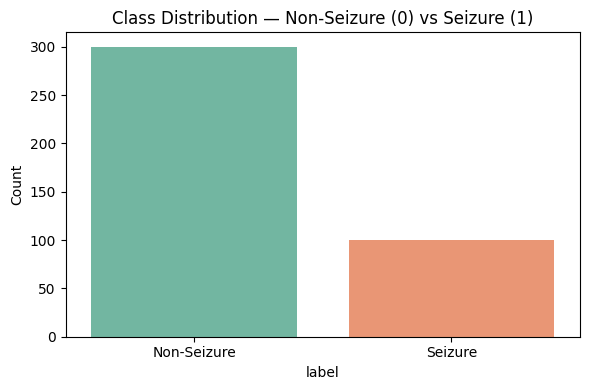

In [256]:
feat_cols = [c for c in df3.columns if c != 'label']
print(f'=== Descriptive Statistics ===')
print(f'Total samples  : {len(df3)}')
print(f'Total features : {len(feat_cols)} (raw EEG signal amplitudes)')
print(f'Value range    : [{df3[feat_cols].min().min():.2f}, {df3[feat_cols].max().max():.2f}]')
print(f'Mean per sample (avg): {df3[feat_cols].mean(axis=1).mean():.2f}')
print()

# Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df3, palette='Set2')
plt.title('Class Distribution — Non-Seizure (0) vs Seizure (1)')
plt.xticks([0, 1], ['Non-Seizure', 'Seizure'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal Sample Visualization

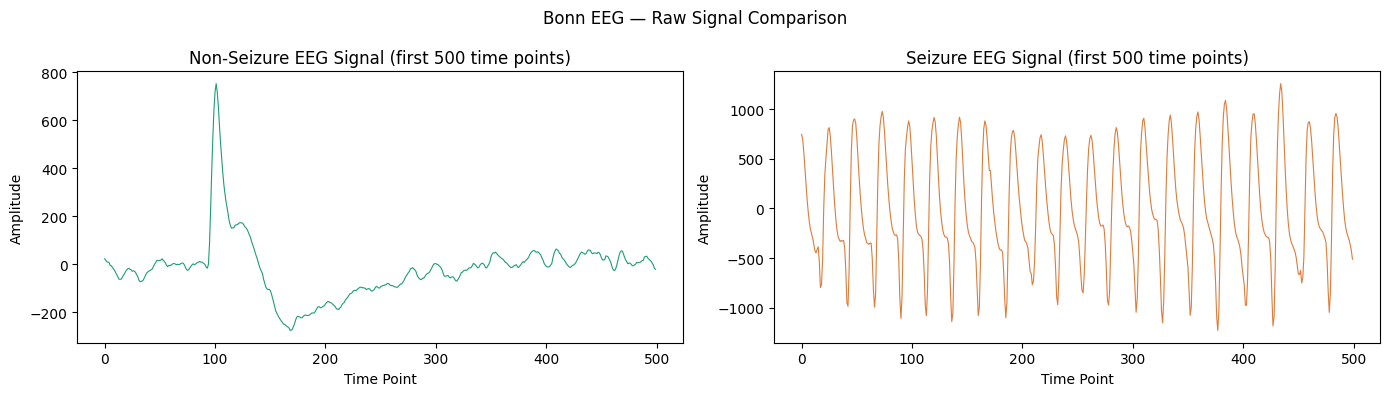

In [257]:
# Plot one sample signal per class to understand the data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

seizure_sample    = df3[df3['label'] == 1].iloc[0][feat_cols].values
nonseizure_sample = df3[df3['label'] == 0].iloc[0][feat_cols].values

axes[0].plot(nonseizure_sample[:500], color='#1D9E75', linewidth=0.8)
axes[0].set_title('Non-Seizure EEG Signal (first 500 time points)')
axes[0].set_xlabel('Time Point'); axes[0].set_ylabel('Amplitude')

axes[1].plot(seizure_sample[:500], color='#E07B39', linewidth=0.8)
axes[1].set_title('Seizure EEG Signal (first 500 time points)')
axes[1].set_xlabel('Time Point'); axes[1].set_ylabel('Amplitude')

plt.suptitle('Bonn EEG — Raw Signal Comparison')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_02_signal_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Missing Value Check

In [258]:
missing = df3.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() == 0:
    print('No missing values. Dataset is complete.')

Total missing values: 0
No missing values. Dataset is complete.


## **Step 2: Preprocessing Pipelines**


## Train/Test Split

In [259]:
# Split BEFORE any preprocessing to prevent data leakage
X3 = df3.drop(columns=['label'])
y3 = df3['label']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)
print(f'Train: {X3_train.shape} | Test: {X3_test.shape}')
print(f'Train class distribution:\n{y3_train.value_counts()}')
print(f'\nNote: Only 400 samples total — small dataset, interpret results cautiously.')

Train: (320, 4097) | Test: (80, 4097)
Train class distribution:
label
0    240
1     80
Name: count, dtype: int64

Note: Only 400 samples total — small dataset, interpret results cautiously.


## Pipeline A — Step 1: Outlier Clipping (IQR)

In [260]:
# Boundaries computed from train only
Q1_3, Q3_3 = X3_train.quantile(0.25), X3_train.quantile(0.75)
IQR3       = Q3_3 - Q1_3
lower3, upper3 = Q1_3 - 1.5 * IQR3, Q3_3 + 1.5 * IQR3

X3_A_tr = X3_train.clip(lower=lower3, upper=upper3, axis=1)
X3_A_te = X3_test.clip(lower=lower3,  upper=upper3, axis=1)
print(f'IQR Clipping done.')
print(f'  Before: [{X3_train.min().min():.2f}, {X3_train.max().max():.2f}]')
print(f'  After : [{X3_A_tr.min().min():.2f}, {X3_A_tr.max().max():.2f}]')

IQR Clipping done.
  Before: [-1885.00, 2047.00]
  After : [-270.12, 237.88]


## Pipeline A — Step 2: MinMax Normalization

In [261]:
# Scaler fitted on train only
scaler3_A = MinMaxScaler()
X3_A_tr   = pd.DataFrame(scaler3_A.fit_transform(X3_A_tr), columns=X3_train.columns)
X3_A_te   = pd.DataFrame(scaler3_A.transform(X3_A_te),     columns=X3_train.columns)
print(f'MinMax Scaling done. Range: [{X3_A_tr.min().min():.2f}, {X3_A_tr.max().max():.2f}]')

MinMax Scaling done. Range: [0.00, 1.00]


## Pipeline A — Step 3: ANOVA Feature Selection (Top 20)

Feature Selection done. Selected 20 of 4097 time-point features.
Selected: ['signal_58', 'signal_362', 'signal_363', 'signal_364', 'signal_365', 'signal_366', 'signal_403', 'signal_404', 'signal_405', 'signal_406', 'signal_2513', 'signal_2514', 'signal_3071', 'signal_3072', 'signal_3073', 'signal_3916', 'signal_3917', 'signal_3918', 'signal_3919', 'signal_3920']


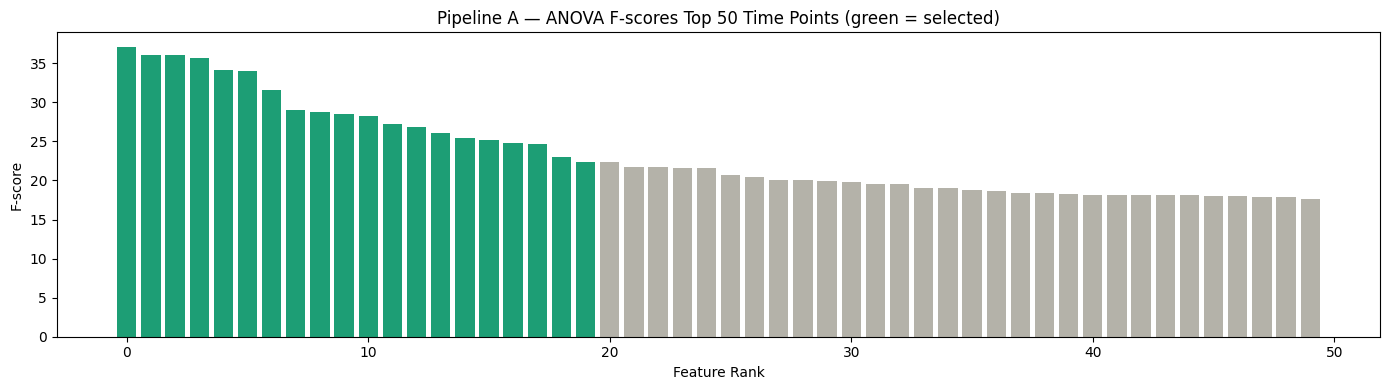

In [262]:
# k=20 selected from 4097 raw signal time-points
# Selector fitted on train only
selector3  = SelectKBest(f_classif, k=20)
X3_A_train = pd.DataFrame(selector3.fit_transform(X3_A_tr, y3_train),
                           columns=X3_train.columns[selector3.get_support()])
X3_A_test  = pd.DataFrame(selector3.transform(X3_A_te),
                           columns=X3_train.columns[selector3.get_support()])

selected3 = X3_A_train.columns.tolist()
print(f'Feature Selection done. Selected 20 of 4097 time-point features.')
print(f'Selected: {selected3}')

# Plot top 50 ANOVA scores
all_scores3 = pd.Series(selector3.scores_, index=X3_train.columns).sort_values(ascending=False)
top50       = all_scores3.head(50)
colors3     = ['#1D9E75' if f in selected3 else '#B4B2A9' for f in top50.index]
plt.figure(figsize=(14, 4))
plt.bar(range(len(top50)), top50.values, color=colors3)
plt.title('Pipeline A — ANOVA F-scores Top 50 Time Points (green = selected)')
plt.xlabel('Feature Rank'); plt.ylabel('F-score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_04_pipeline_A_anova.png', dpi=150, bbox_inches='tight')
plt.show()

## Pipeline B — Step 1: Z-score Standardization

In [263]:
# Scaler fitted on train only
scaler3_B = StandardScaler()
X3_B_tr   = pd.DataFrame(scaler3_B.fit_transform(X3_train), columns=X3_train.columns)
X3_B_te   = pd.DataFrame(scaler3_B.transform(X3_test),      columns=X3_train.columns)
print(f'Standardization done. Mean~0: {X3_B_tr.mean().mean():.4f}, Std~1: {X3_B_tr.std().mean():.4f}')

Standardization done. Mean~0: 0.0000, Std~1: 1.0016


## Pipeline B — Step 2: PCA (95% Variance)

PCA done. Original: 4097 features → 82 components
Variance retained: 95.08%


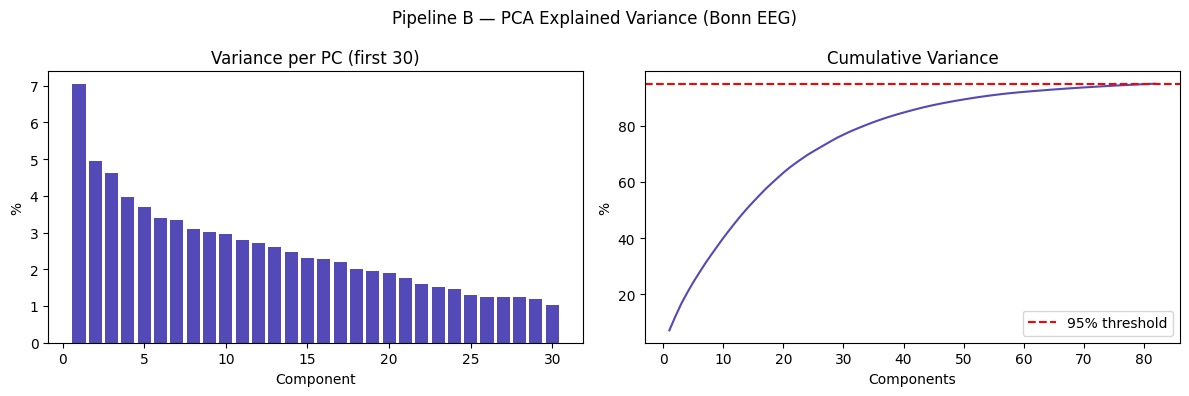

In [264]:
# PCA fitted on train only — 4097 raw features will compress significantly
pca3      = PCA(n_components=0.95, random_state=42)
pca3.fit(X3_B_tr)
pc_cols3  = [f'PC{i+1}' for i in range(pca3.n_components_)]
X3_B_train = pd.DataFrame(pca3.transform(X3_B_tr), columns=pc_cols3)
X3_B_test  = pd.DataFrame(pca3.transform(X3_B_te), columns=pc_cols3)
cum_var3   = np.cumsum(pca3.explained_variance_ratio_)
print(f'PCA done. Original: 4097 features → {pca3.n_components_} components')
print(f'Variance retained: {cum_var3[-1]*100:.2f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, min(31, len(pc_cols3)+1)),
            pca3.explained_variance_ratio_[:30]*100, color='#534AB7')
axes[0].set_title('Variance per PC (first 30)'); axes[0].set_ylabel('%')
axes[0].set_xlabel('Component')
axes[1].plot(range(1, len(pc_cols3)+1), cum_var3*100, color='#534AB7', linewidth=1.5)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Variance'); axes[1].set_ylabel('%')
axes[1].set_xlabel('Components'); axes[1].legend()
plt.suptitle('Pipeline B — PCA Explained Variance (Bonn EEG)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_05_pipeline_B_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 3: Baseline Logistic Regression**

## Train Baseline Model

In [265]:
lr3_A = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
lr3_B = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
lr3_A.fit(X3_A_train, y3_train)
lr3_B.fit(X3_B_train, y3_train)

def get_metrics3(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    p, r, _ = precision_recall_curve(y_te, y_prob)
    pr_auc   = auc(r, p)
    print(f'{name} → Accuracy: {acc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f}')
    return {'name': name, 'accuracy': acc, 'f1': f1, 'pr_auc': pr_auc}

print('=== Baseline Results ===')
res3_A = get_metrics3(lr3_A, X3_A_test, y3_test, 'Pipeline A')
res3_B = get_metrics3(lr3_B, X3_B_test, y3_test, 'Pipeline B')

=== Baseline Results ===
Pipeline A → Accuracy: 0.7500 | F1: 0.4444 | PR-AUC: 0.5406
Pipeline B → Accuracy: 0.8875 | F1: 0.7273 | PR-AUC: 0.6822


## Classification Report

In [266]:
labels = ['Non-Seizure', 'Seizure']
print('=== Pipeline A — Classification Report ===')
print(classification_report(y3_test, lr3_A.predict(X3_A_test), target_names=labels))
print('=== Pipeline B — Classification Report ===')
print(classification_report(y3_test, lr3_B.predict(X3_B_test), target_names=labels))

=== Pipeline A — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.81      0.87      0.84        60
     Seizure       0.50      0.40      0.44        20

    accuracy                           0.75        80
   macro avg       0.66      0.63      0.64        80
weighted avg       0.73      0.75      0.74        80

=== Pipeline B — Classification Report ===
              precision    recall  f1-score   support

 Non-Seizure       0.88      0.98      0.93        60
     Seizure       0.92      0.60      0.73        20

    accuracy                           0.89        80
   macro avg       0.90      0.79      0.83        80
weighted avg       0.89      0.89      0.88        80



## Confusion Matrix

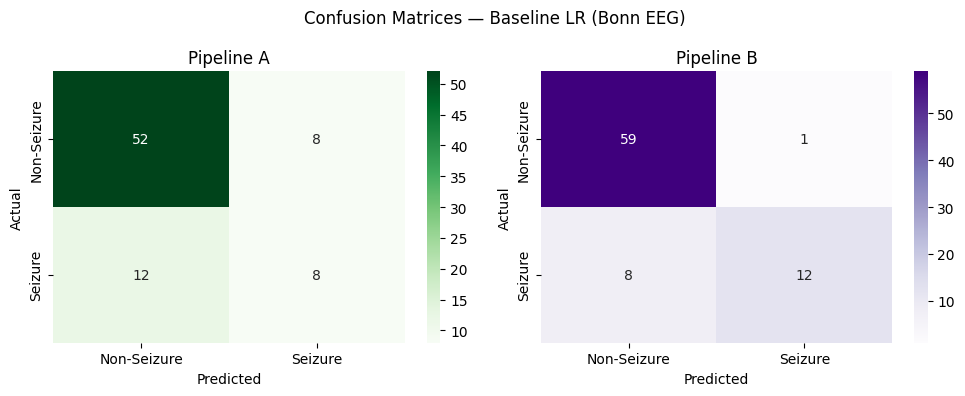

In [267]:
labels = ['Non-Seizure', 'Seizure']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, X_te, title, cmap in zip(
    axes, [lr3_A, lr3_B], [X3_A_test, X3_B_test],
    ['Pipeline A', 'Pipeline B'], ['Greens', 'Purples']
):
    cm = confusion_matrix(y3_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Baseline LR (Bonn EEG)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_06_baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Baseline Results Comparison

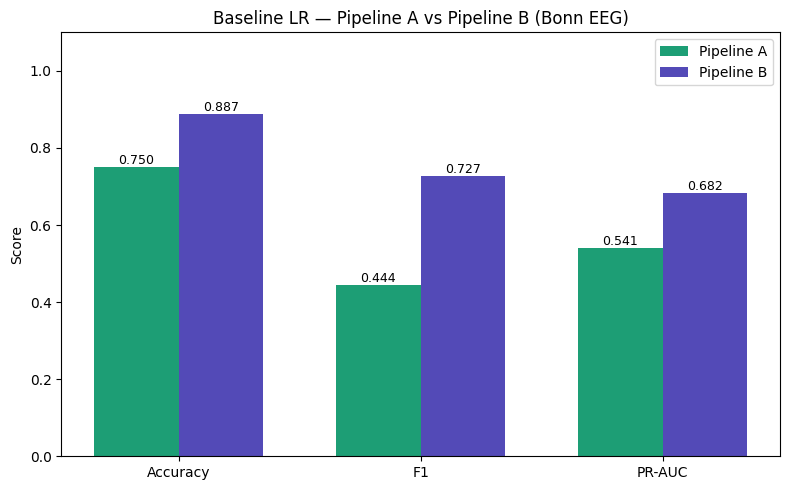

In [268]:
metrics_keys   = ['accuracy', 'f1', 'pr_auc']
metrics_labels = ['Accuracy', 'F1', 'PR-AUC']
x = np.arange(len(metrics_keys)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [res3_A[m] for m in metrics_keys], w, label='Pipeline A', color='#1D9E75')
ax.bar(x + w/2, [res3_B[m] for m in metrics_keys], w, label='Pipeline B', color='#534AB7')
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Baseline LR — Pipeline A vs Pipeline B (Bonn EEG)')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_07_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 4: Overfitting & Underfitting**

## Underfitting Scenario

In [269]:
# Only 2 features from ANOVA-selected 20 + very strong regularization
X3_u_tr = X3_A_train.iloc[:, :2]
X3_u_te = X3_A_test.iloc[:, :2]

lr3_under = LogisticRegression(C=0.0001, max_iter=2000, random_state=42)
lr3_under.fit(X3_u_tr, y3_train)

tr_acc = lr3_under.score(X3_u_tr, y3_train)
te_acc = lr3_under.score(X3_u_te, y3_test)
print('=== Underfitting Scenario ===')
print(f'Features used  : {X3_u_tr.columns.tolist()}')
print(f'C              : 0.0001 (very strong regularization)')
print(f'Train Accuracy : {tr_acc:.4f}')
print(f'Test  Accuracy : {te_acc:.4f}')
print(f'Gap            : {tr_acc - te_acc:.4f}')
print('Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)')

=== Underfitting Scenario ===
Features used  : ['signal_58', 'signal_362']
C              : 0.0001 (very strong regularization)
Train Accuracy : 0.7500
Test  Accuracy : 0.7500
Gap            : 0.0000
Diagnosis      : Both low = HIGH BIAS (underfitting confirmed)


## Overfitting Scenario

In [270]:
# Polynomial degree=2 on 20 selected features + no regularization
# degree=2 gives 230 features — manageable for small dataset
poly3   = PolynomialFeatures(degree=2, include_bias=False)
X3_o_tr = poly3.fit_transform(X3_A_train)
X3_o_te = poly3.transform(X3_A_test)

lr3_over = LogisticRegression(C=10000, max_iter=2000, random_state=42)
lr3_over.fit(X3_o_tr, y3_train)

tr_acc = lr3_over.score(X3_o_tr, y3_train)
te_acc = lr3_over.score(X3_o_te, y3_test)
print('=== Overfitting Scenario ===')
print(f'Features after polynomial expansion : {X3_o_tr.shape[1]}')
print(f'C                                   : 10000 (minimal regularization)')
print(f'Train Accuracy                      : {tr_acc:.4f}')
print(f'Test  Accuracy                      : {te_acc:.4f}')
print(f'Gap                                 : {tr_acc - te_acc:.4f}')
print('NOTE: Small gap expected — LR is structurally resistant to overfitting.')
print('NOTE: With only 320 training samples, overfitting risk is higher than in BEED/UCI.')

=== Overfitting Scenario ===
Features after polynomial expansion : 230
C                                   : 10000 (minimal regularization)
Train Accuracy                      : 1.0000
Test  Accuracy                      : 0.8750
Gap                                 : 0.1250
NOTE: Small gap expected — LR is structurally resistant to overfitting.
NOTE: With only 320 training samples, overfitting risk is higher than in BEED/UCI.


## Validation Curve

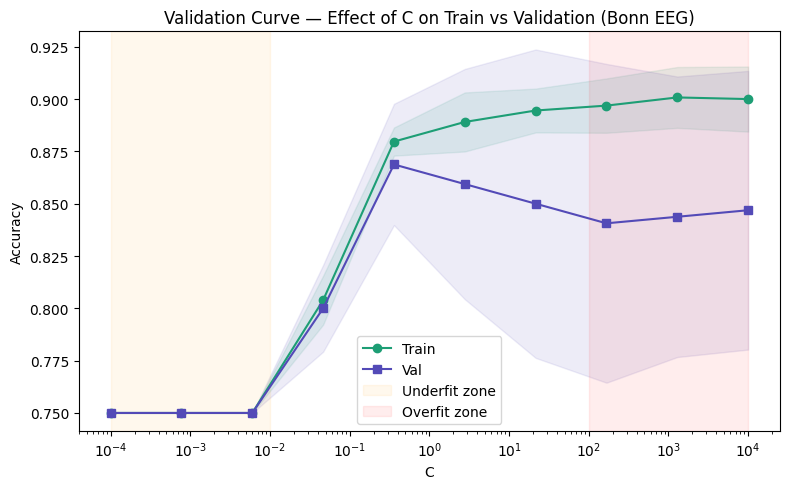

In [271]:
C_range3 = np.logspace(-4, 4, 10)
tr_scores3, val_scores3 = validation_curve(
    LogisticRegression(max_iter=2000, random_state=42),
    X3_A_train, y3_train, param_name='C', param_range=C_range3,
    cv=5, scoring='accuracy', n_jobs=-1
)
tr_mean3, tr_std3 = tr_scores3.mean(axis=1), tr_scores3.std(axis=1)
v_mean3,  v_std3  = val_scores3.mean(axis=1), val_scores3.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(C_range3, tr_mean3, label='Train', color='#1D9E75', marker='o')
plt.semilogx(C_range3, v_mean3,  label='Val',   color='#534AB7', marker='s')
plt.fill_between(C_range3, tr_mean3-tr_std3, tr_mean3+tr_std3, alpha=0.1, color='#1D9E75')
plt.fill_between(C_range3, v_mean3-v_std3,   v_mean3+v_std3,   alpha=0.1, color='#534AB7')
plt.axvspan(1e-4, 1e-2, alpha=0.07, color='orange', label='Underfit zone')
plt.axvspan(1e2,  1e4,  alpha=0.07, color='red',    label='Overfit zone')
plt.xlabel('C'); plt.ylabel('Accuracy')
plt.title('Validation Curve — Effect of C on Train vs Validation (Bonn EEG)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_08_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Curves

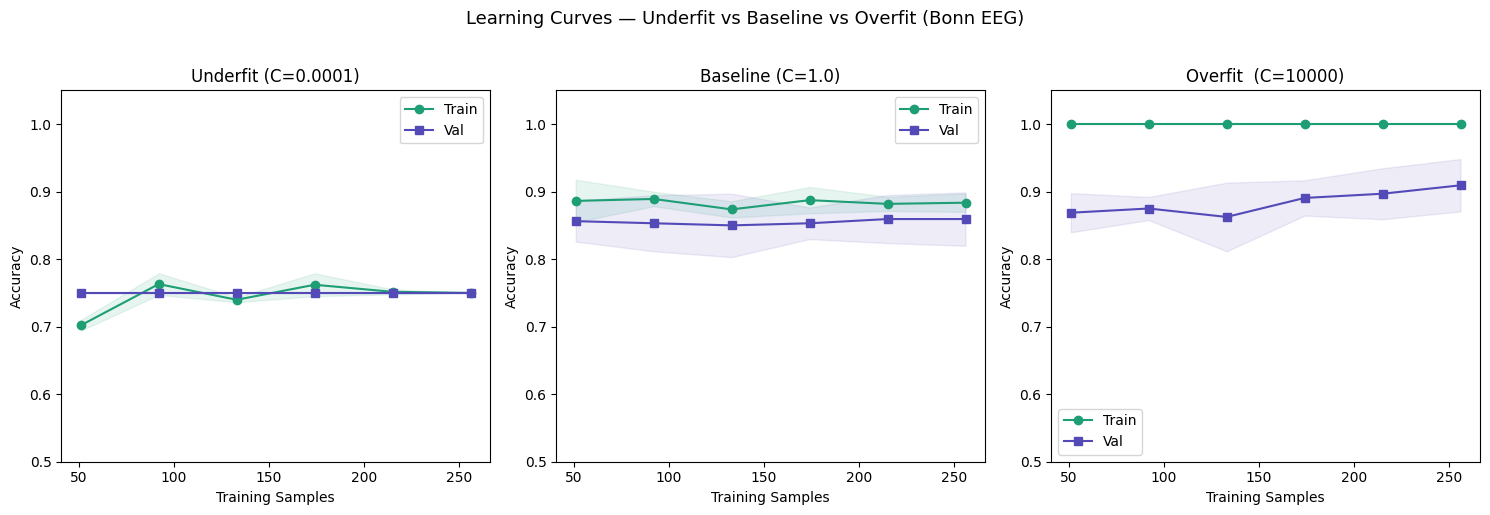

In [272]:
# Fewer train_sizes because dataset is small (320 samples)
train_sizes3 = np.linspace(0.2, 1.0, 6)
scenarios3   = [
    ('Underfit (C=0.0001)', LogisticRegression(C=0.0001, max_iter=2000, random_state=42), X3_u_tr, y3_train),
    ('Baseline (C=1.0)',    LogisticRegression(C=1.0,    max_iter=2000, random_state=42), X3_A_train, y3_train),
    ('Overfit  (C=10000)',  LogisticRegression(C=10000,  max_iter=2000, random_state=42), X3_o_tr, y3_train),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, model, X_lc, y_lc) in zip(axes, scenarios3):
    sizes, tr_s, v_s = learning_curve(
        model, X_lc, y_lc, train_sizes=train_sizes3, cv=5,
        scoring='accuracy', n_jobs=-1
    )
    ax.plot(sizes, tr_s.mean(axis=1), label='Train', color='#1D9E75', marker='o')
    ax.plot(sizes, v_s.mean(axis=1),  label='Val',   color='#534AB7', marker='s')
    ax.fill_between(sizes, tr_s.mean(axis=1)-tr_s.std(axis=1),
                           tr_s.mean(axis=1)+tr_s.std(axis=1), alpha=0.1, color='#1D9E75')
    ax.fill_between(sizes, v_s.mean(axis=1)-v_s.std(axis=1),
                           v_s.mean(axis=1)+v_s.std(axis=1),   alpha=0.1, color='#534AB7')
    ax.set_title(label); ax.set_xlabel('Training Samples'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.set_ylim(0.5, 1.05)
plt.suptitle('Learning Curves — Underfit vs Baseline vs Overfit (Bonn EEG)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_09_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting & Underfitting Results Summary

In [273]:
summary_ou3 = pd.DataFrame([
    {'Scenario': 'Underfitting', 'C': 0.0001, 'Features': 2,
     'Train Acc': round(lr3_under.score(X3_u_tr, y3_train), 4),
     'Test Acc' : round(lr3_under.score(X3_u_te, y3_test),  4)},
    {'Scenario': 'Baseline',    'C': 1.0,    'Features': X3_A_train.shape[1],
     'Train Acc': round(lr3_A.score(X3_A_train, y3_train),  4),
     'Test Acc' : round(lr3_A.score(X3_A_test,  y3_test),   4)},
    {'Scenario': 'Overfitting', 'C': 10000,  'Features': X3_o_tr.shape[1],
     'Train Acc': round(lr3_over.score(X3_o_tr, y3_train),  4),
     'Test Acc' : round(lr3_over.score(X3_o_te, y3_test),   4)},
])
summary_ou3['Gap'] = (summary_ou3['Train Acc'] - summary_ou3['Test Acc']).round(4)
print('=== Overfitting / Underfitting Results Summary (Bonn EEG) ===')
summary_ou3

=== Overfitting / Underfitting Results Summary (Bonn EEG) ===


,Scenario,C,Features,Train Acc,Test Acc,Gap
0,Underfitting,0.0001,2,0.7500,0.750,0.0000
1,Baseline,1.0000,20,0.8438,0.750,0.0938
2,Overfitting,10000.0000,230,1.0000,0.875,0.1250


## **Step 5: Regularization Study**

## Train L1, L2 and ElasticNet

In [274]:
reg_configs3 = {
    'L1 (Lasso)': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000, random_state=42, class_weight='balanced'),
    'L2 (Ridge)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',     max_iter=2000, random_state=42, class_weight='balanced'),
    'ElasticNet' : SGDClassifier(loss='modified_huber', penalty='elasticnet',
                                 l1_ratio=0.5, alpha=0.001, max_iter=2000, random_state=42, class_weight='balanced'),
}

trained3_A, trained3_B, reg_rows3 = {}, {}, []
for name, model in reg_configs3.items():
    m_A = copy.deepcopy(model); m_A.fit(X3_A_train, y3_train); trained3_A[name] = m_A
    m_B = copy.deepcopy(model); m_B.fit(X3_B_train, y3_train); trained3_B[name] = m_B
    for pipe, m, X_te in [('Pipeline A', m_A, X3_A_test), ('Pipeline B', m_B, X3_B_test)]:
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y3_test, y_prob)
        reg_rows3.append({'Regularizer': name, 'Pipeline': pipe,
                          'Accuracy': round(accuracy_score(y3_test, y_pred), 4),
                          'F1':       round(f1_score(y3_test, y_pred), 4),
                          'PR-AUC':   round(auc(r, p), 4)})

reg3_metrics_df = pd.DataFrame(reg_rows3)
print('=== Regularization Metrics (Bonn EEG) ===')
print(reg3_metrics_df.to_string(index=False))

=== Regularization Metrics (Bonn EEG) ===
Regularizer   Pipeline  Accuracy     F1  PR-AUC
 L1 (Lasso) Pipeline A    0.7750 0.5000  0.5506
 L1 (Lasso) Pipeline B    0.8875 0.7273  0.7085
 L2 (Ridge) Pipeline A    0.7500 0.4444  0.5406
 L2 (Ridge) Pipeline B    0.8875 0.7273  0.6822
 ElasticNet Pipeline A    0.7625 0.4865  0.5250
 ElasticNet Pipeline B    0.8250 0.6111  0.6750


## Coefficient Sparsity Analysis

=== Sparsity Analysis (Pipeline A — Bonn EEG) ===
  L1 (Lasso)      → Zero coefficients: 8/20 | Sparsity: 40.0%
  L2 (Ridge)      → Zero coefficients: 0/20 | Sparsity: 0.0%
  ElasticNet      → Zero coefficients: 4/20 | Sparsity: 20.0%


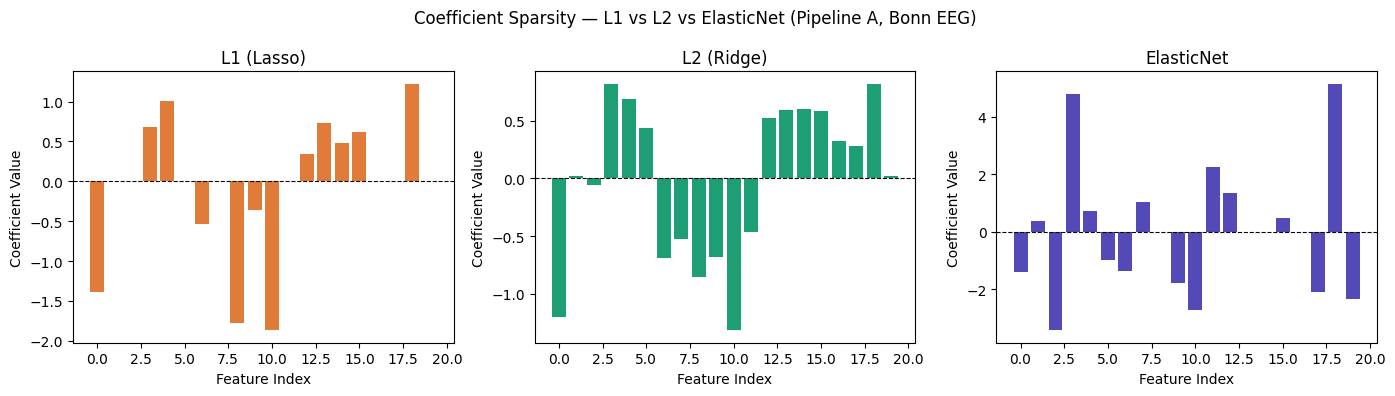

In [275]:
print('=== Sparsity Analysis (Pipeline A — Bonn EEG) ===')
for name, model in trained3_A.items():
    if hasattr(model, 'coef_'):
        coefs = model.coef_.flatten()
        zeros = (np.abs(coefs) < 1e-4).sum()
        print(f'  {name:15} → Zero coefficients: {zeros}/{len(coefs)} | Sparsity: {zeros/len(coefs)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model), color in zip(axes, trained3_A.items(), ['#E07B39', '#1D9E75', '#534AB7']):
    coefs = model.coef_.flatten()
    ax.bar(range(len(coefs)), coefs, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(name); ax.set_xlabel('Feature Index'); ax.set_ylabel('Coefficient Value')
plt.suptitle('Coefficient Sparsity — L1 vs L2 vs ElasticNet (Pipeline A, Bonn EEG)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_10_coefficient_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Path — L1 vs L2

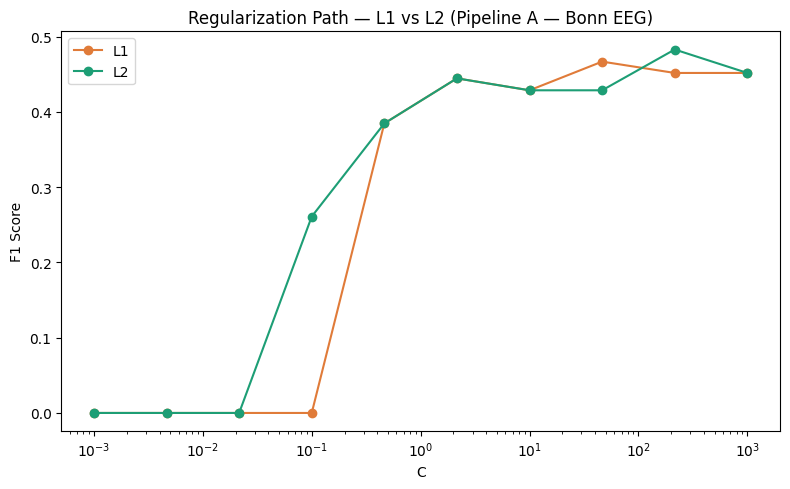

In [276]:
C_range3p = np.logspace(-3, 3, 10)
plt.figure(figsize=(8, 5))
for penalty, solver, color, label in [
    ('l1', 'liblinear', '#E07B39', 'L1'),
    ('l2', 'lbfgs',     '#1D9E75', 'L2'),
]:
    f1s = []
    for C in C_range3p:
        m = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=2000, random_state=42)
        m.fit(X3_A_train, y3_train)
        f1s.append(f1_score(y3_test, m.predict(X3_A_test)))
    plt.semilogx(C_range3p, f1s, marker='o', color=color, label=label)
plt.xlabel('C'); plt.ylabel('F1 Score')
plt.title('Regularization Path — L1 vs L2 (Pipeline A — Bonn EEG)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bonn_12_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

## Regularization Results Summary

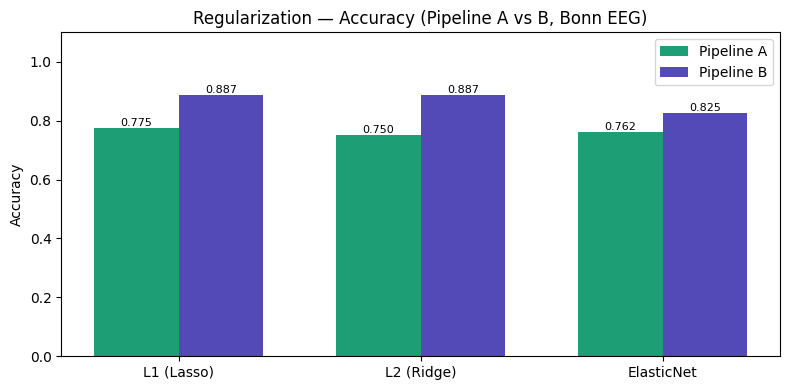

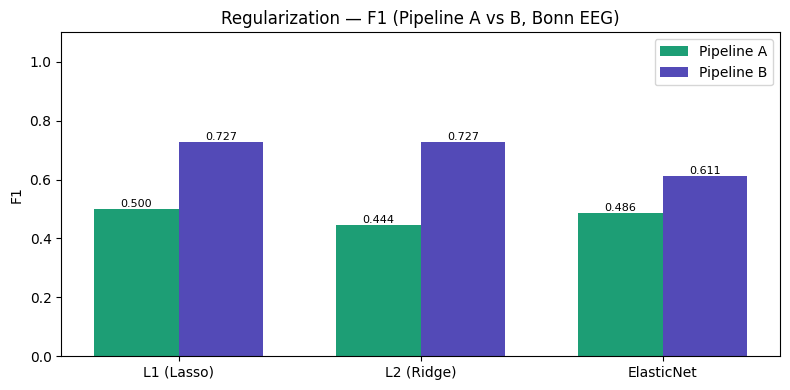

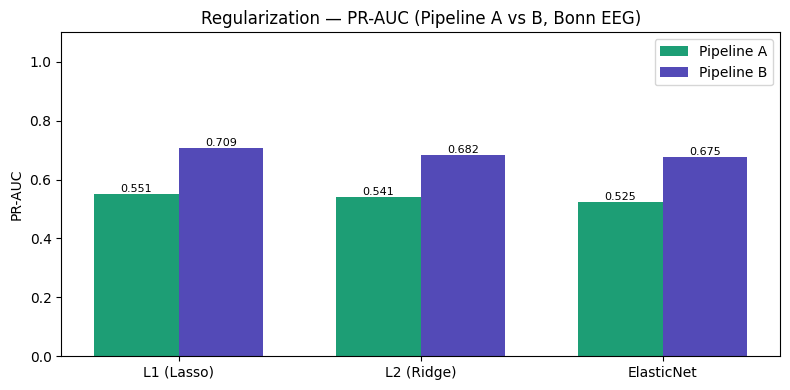

In [277]:
reg_names3 = reg3_metrics_df['Regularizer'].unique().tolist()
x3 = np.arange(len(reg_names3)); w3 = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [reg3_metrics_df[(reg3_metrics_df.Regularizer==n) & (reg3_metrics_df.Pipeline=='Pipeline A')][metric].values[0] for n in reg_names3]
    vals_B = [reg3_metrics_df[(reg3_metrics_df.Regularizer==n) & (reg3_metrics_df.Pipeline=='Pipeline B')][metric].values[0] for n in reg_names3]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x3 - w3/2, vals_A, w3, label='Pipeline A', color='#1D9E75')
    ax.bar(x3 + w3/2, vals_B, w3, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x3); ax.set_xticklabels(reg_names3)
    ax.set_ylim(0, 1.1); ax.set_ylabel(metric)
    ax.set_title(f'Regularization — {metric} (Pipeline A vs B, Bonn EEG)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/bonn_13_reg_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## **Step 6: Class Imbalance Handling**

## Apply Sampling Techniques

In [278]:
smote3 = SMOTE(random_state=42)
rus3   = RandomUnderSampler(random_state=42)

X3_smote_A, y3_smote_A = smote3.fit_resample(X3_A_train, y3_train)
X3_under_A, y3_under_A = rus3.fit_resample(X3_A_train,   y3_train)
X3_smote_B, y3_smote_B = smote3.fit_resample(X3_B_train, y3_train)
X3_under_B, y3_under_B = rus3.fit_resample(X3_B_train,   y3_train)

configs3 = {
    'Baseline'     : {'A': (X3_A_train, y3_train),   'B': (X3_B_train, y3_train),   'cw': 'balanced'},
    'SMOTE'        : {'A': (X3_smote_A, y3_smote_A), 'B': (X3_smote_B, y3_smote_B), 'cw': None},
    'Undersampling': {'A': (X3_under_A, y3_under_A), 'B': (X3_under_B, y3_under_B), 'cw': None},
    'Class Weight' : {'A': (X3_A_train, y3_train),   'B': (X3_B_train, y3_train),   'cw': 'balanced'},
}

imb3_trained, imb3_rows = {}, []
for name, data in configs3.items():
    for pipe, X_te in [('A', X3_A_test), ('B', X3_B_test)]:
        X_tr, y_tr = data[pipe]
        m = LogisticRegression(class_weight=data['cw'], max_iter=2000, random_state=42)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1]
        p, r, _ = precision_recall_curve(y3_test, y_prob)
        imb3_rows.append({
            'Technique': name, 'Pipeline': f'Pipeline {pipe}',
            'Accuracy' : round(accuracy_score(y3_test, y_pred), 4),
            'F1'       : round(f1_score(y3_test, y_pred), 4),
            'PR-AUC'   : round(auc(r, p), 4),
        })
        imb3_trained[f'{name}_{pipe}'] = m

imb3_df = pd.DataFrame(imb3_rows)
print('=== Imbalance Handling Results (Bonn EEG) ===')
print(imb3_df.to_string(index=False))

=== Imbalance Handling Results (Bonn EEG) ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.7500 0.4444  0.5406
     Baseline Pipeline B    0.8875 0.7273  0.6822
        SMOTE Pipeline A    0.7625 0.4571  0.5209
        SMOTE Pipeline B    0.8875 0.7273  0.6867
Undersampling Pipeline A    0.7625 0.4571  0.5506
Undersampling Pipeline B    0.8750 0.6875  0.6402
 Class Weight Pipeline A    0.7500 0.4444  0.5406
 Class Weight Pipeline B    0.8875 0.7273  0.6822


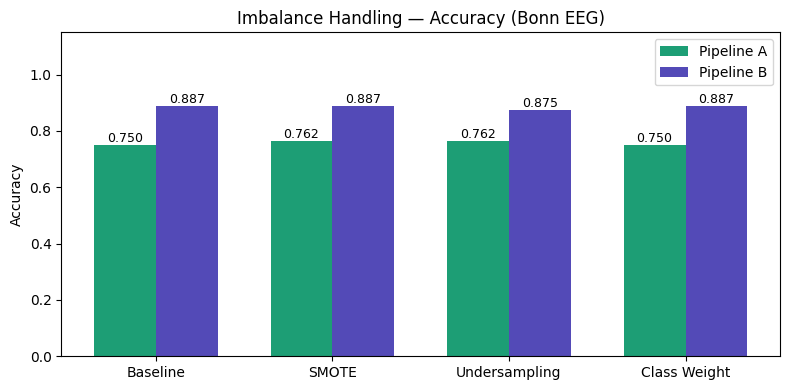

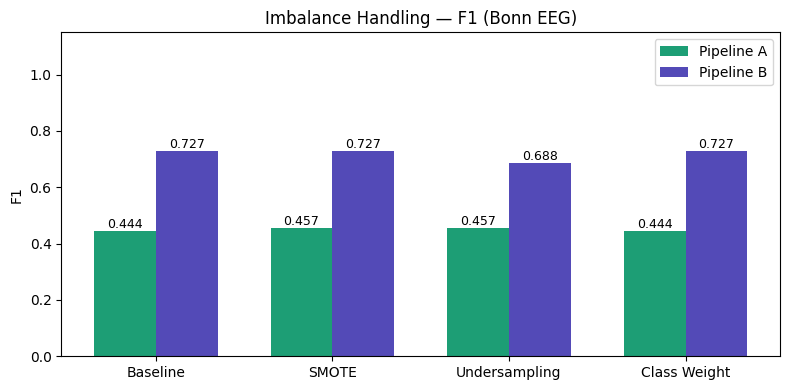

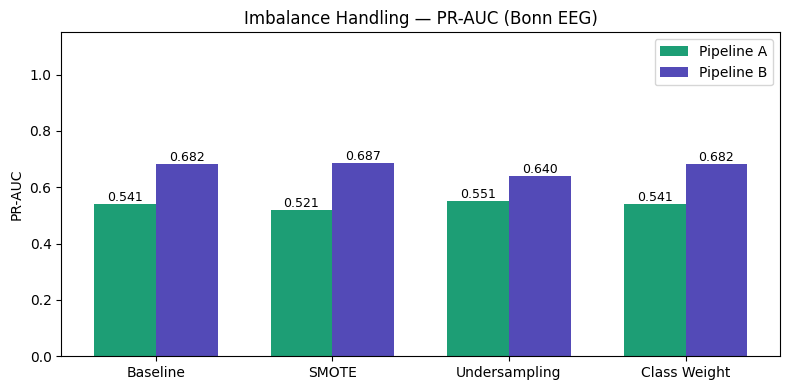

In [279]:
techniques3 = list(configs3.keys())
x = np.arange(len(techniques3)); w = 0.35

for metric in ['Accuracy', 'F1', 'PR-AUC']:
    vals_A = [imb3_df[(imb3_df.Technique==t) & (imb3_df.Pipeline=='Pipeline A')][metric].values[0] for t in techniques3]
    vals_B = [imb3_df[(imb3_df.Technique==t) & (imb3_df.Pipeline=='Pipeline B')][metric].values[0] for t in techniques3]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, vals_A, w, label='Pipeline A', color='#1D9E75')
    ax.bar(x + w/2, vals_B, w, label='Pipeline B', color='#534AB7')
    ax.set_xticks(x); ax.set_xticklabels(techniques3)
    ax.set_ylim(0, 1.15); ax.set_ylabel(metric)
    ax.set_title(f'Imbalance Handling — {metric} (Bonn EEG)')
    ax.legend()
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/bonn_imbalance_{metric.lower().replace("-","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Classification Reports

In [280]:
labels_cls = ['Non-Seizure', 'Seizure']
for pipe, X_te in [('A', X3_A_test), ('B', X3_B_test)]:
    print(f'\n{"="*55}')
    print(f'  Pipeline {pipe} — Classification Reports (Bonn EEG)')
    print(f'{"="*55}')
    for tech in techniques3:
        y_pred = imb3_trained[f'{tech}_{pipe}'].predict(X_te)
        print(f'\n--- {tech} ---')
        print(classification_report(y3_test, y_pred, target_names=labels_cls, zero_division=0))


  Pipeline A — Classification Reports (Bonn EEG)

--- Baseline ---
              precision    recall  f1-score   support

 Non-Seizure       0.81      0.87      0.84        60
     Seizure       0.50      0.40      0.44        20

    accuracy                           0.75        80
   macro avg       0.66      0.63      0.64        80
weighted avg       0.73      0.75      0.74        80


--- SMOTE ---
              precision    recall  f1-score   support

 Non-Seizure       0.82      0.88      0.85        60
     Seizure       0.53      0.40      0.46        20

    accuracy                           0.76        80
   macro avg       0.67      0.64      0.65        80
weighted avg       0.74      0.76      0.75        80


--- Undersampling ---
              precision    recall  f1-score   support

 Non-Seizure       0.82      0.88      0.85        60
     Seizure       0.53      0.40      0.46        20

    accuracy                           0.76        80
   macro avg       0.6

## Confusion Matrices

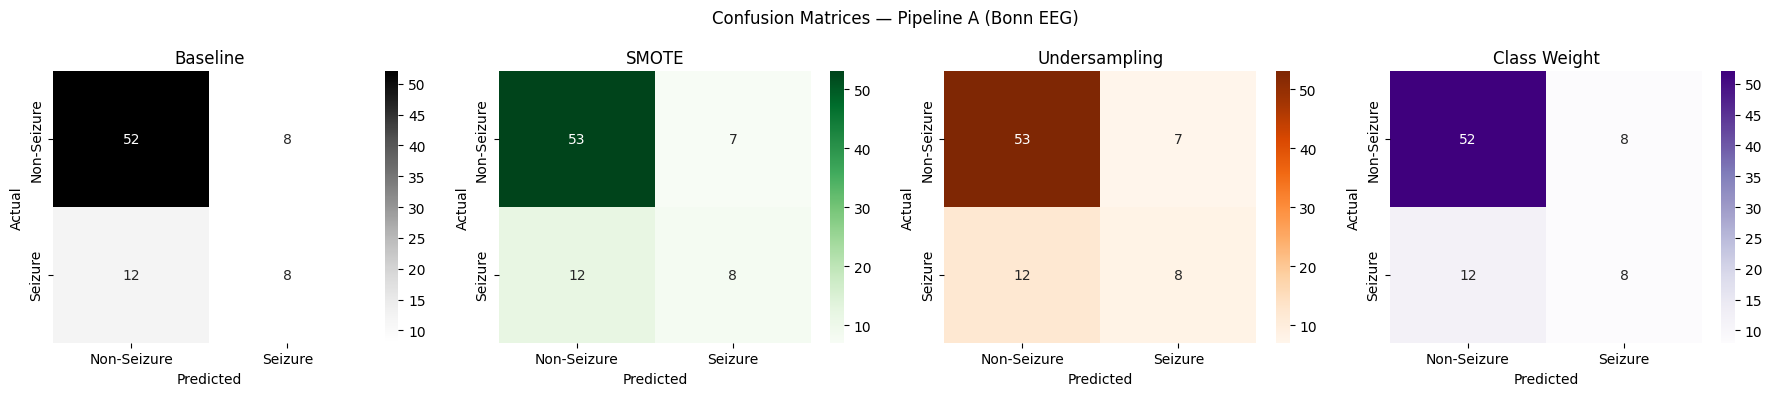

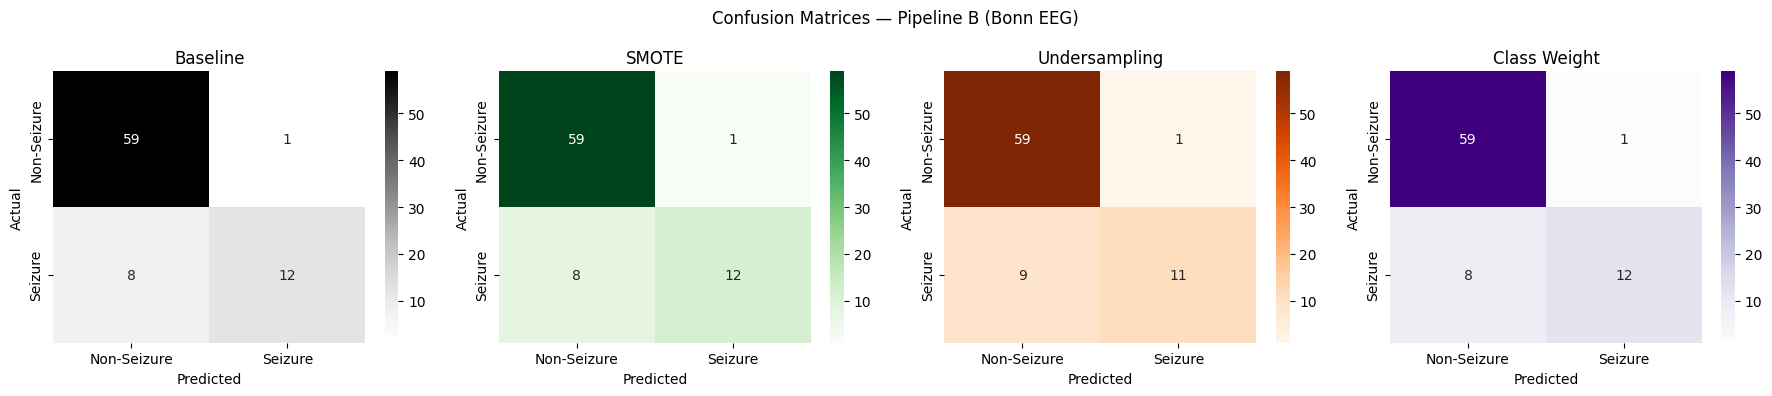

In [281]:
labels_cls = ['Non-Seizure', 'Seizure']
cmaps_all  = ['Greys', 'Greens', 'Oranges', 'Purples']
for pipe, X_te in [('A', X3_A_test), ('B', X3_B_test)]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, tech, cmap in zip(axes, techniques3, cmaps_all):
        cm = confusion_matrix(y3_test, imb3_trained[f'{tech}_{pipe}'].predict(X_te))
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                    xticklabels=labels_cls, yticklabels=labels_cls)
        ax.set_title(tech); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'Confusion Matrices — Pipeline {pipe} (Bonn EEG)')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/bonn_16_cm_pipeline_{pipe}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Final Results Summary

In [282]:
cols = ['Technique', 'Pipeline', 'Accuracy', 'F1', 'PR-AUC']

print('=== Final Results — Class Imbalance Handling (Bonn EEG) ===')
print(imb3_df[cols].to_string(index=False))

print('\n=== Best Technique per Pipeline ===')

for pipe in ['Pipeline A', 'Pipeline B']:

    subset = imb3_df[imb3_df['Pipeline'] == pipe]

    # Best based on F1 Score
    best_f1 = subset.loc[subset['F1'].idxmax()]

    # Best based on Accuracy
    best_acc = subset.loc[subset['Accuracy'].idxmax()]

    print(f'\n{pipe}')
    print(f'Best by F1 Score  → {best_f1["Technique"]:15} | F1: {best_f1["F1"]:.4f} | Accuracy: {best_f1["Accuracy"]:.4f}')
    print(f'Best by Accuracy → {best_acc["Technique"]:15} | Accuracy: {best_acc["Accuracy"]:.4f} | F1: {best_acc["F1"]:.4f}')

=== Final Results — Class Imbalance Handling (Bonn EEG) ===
    Technique   Pipeline  Accuracy     F1  PR-AUC
     Baseline Pipeline A    0.7500 0.4444  0.5406
     Baseline Pipeline B    0.8875 0.7273  0.6822
        SMOTE Pipeline A    0.7625 0.4571  0.5209
        SMOTE Pipeline B    0.8875 0.7273  0.6867
Undersampling Pipeline A    0.7625 0.4571  0.5506
Undersampling Pipeline B    0.8750 0.6875  0.6402
 Class Weight Pipeline A    0.7500 0.4444  0.5406
 Class Weight Pipeline B    0.8875 0.7273  0.6822

=== Best Technique per Pipeline ===

Pipeline A
Best by F1 Score  → SMOTE           | F1: 0.4571 | Accuracy: 0.7625
Best by Accuracy → SMOTE           | Accuracy: 0.7625 | F1: 0.4571

Pipeline B
Best by F1 Score  → Baseline        | F1: 0.7273 | Accuracy: 0.8875
Best by Accuracy → Baseline        | Accuracy: 0.8875 | F1: 0.7273


In [283]:
import glob
print('\n=== Figures saved ===')
for f in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print(f'  {os.path.basename(f)}')


=== Figures saved ===
  beed_01_class_distribution.png
  beed_02_correlation_heatmap.png
  beed_03_missing_values.png
  beed_04_pipeline_A_anova.png
  beed_05_pipeline_B_pca.png
  beed_06_baseline_cm.png
  beed_07_baseline_comparison.png
  beed_08_validation_curve.png
  beed_09_learning_curves.png
  beed_10_coefficient_sparsity.png
  beed_11_l1_sparsity.png
  beed_12_regularization_path.png
  beed_13_reg_accuracy.png
  beed_13_reg_f1.png
  beed_13_reg_pr_auc.png
  beed_14_pr_curves.png
  beed_15_precision_recall_tradeoff.png
  beed_16_cm_pipeline_A.png
  beed_16_cm_pipeline_B.png
  bonn_01_class_distribution.png
  bonn_02_signal_samples.png
  bonn_03_missing_values.png
  bonn_04_pipeline_A_anova.png
  bonn_05_pipeline_B_pca.png
  bonn_06_baseline_cm.png
  bonn_07_baseline_comparison.png
  bonn_08_validation_curve.png
  bonn_09_learning_curves.png
  bonn_10_coefficient_sparsity.png
  bonn_11_l1_sparsity.png
  bonn_12_regularization_path.png
  bonn_13_reg_accuracy.png
  bonn_13_reg_f1.p